In [2]:
# GENERAL USE LIBRARY IMPORTS

import numpy as np, numpy.random
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import datetime as dt
import calendar
from sklearn.linear_model import LinearRegression
import plotly.express as px
from IPython.display import Markdown as md
import random as rand
from matplotlib import gridspec
import yfinance as yf
from datetime import datetime
import getFamaFrenchFactors as gff
from pandas.tseries.offsets import DateOffset
from statsmodels.formula.api import ols
import statsmodels.api as sm
import random
yf.pdr_override()

# OPTIMIZATION LIBRARY IMPORTS
import pulp
from pulp import *
from sklearn.preprocessing import LabelEncoder

In [3]:
#Getting SP_500 Tickers as a list
list_of_dfs = pd.read_html('https://en.wikipedia.org/wiki/List_of_S%26P_500_companies')
wikitable_sp_500 = list_of_dfs[0]
sp500_symbols = wikitable_sp_500['Symbol']

In [ ]:
#Converting SP_500 tickers into list
tickers = sp500_symbols.to_list()
#Remove some tickers as they create an error for the yfinance api
tickers[65] = 'BRK-B'
tickers[81] = 'BF-B'
tickers.remove('BF-B')
tickers.remove('BRK-B')

In [ ]:
#Example List of Tickers in Portfolio

#tickers = ['AXP','AMGN','AAPL','BA','CRM','CSCO','CVX','DIS','DD','HD','HON','IBM','INTC','JNJ','JPM','KO','MCD','MMM','MRK','MSFT','NKE','TRV','VZ','V','WBA','WMT']

#tickers = ['AAPL', 'ABT', 'ACN','ACGL', 'ADBE', 'AIG', 'AMD','AMCR','AMGN', 'AMT', 'AMZN', 'AXP', 'BA', 'BAC', 'BK', 'BKNG', 'BLK', 'BMY', 'C', 'CAT', 'CHTR', 'CL', 'COF', 'COP', 'COST', 'CRM', 'CSCO', 'CVS', 'CVX','DIS', 'DUK', 'EMR', 'EXC', 'F', 'FDX', 'GD', 'GE', 'GILD', 'GM', 'GOOG', 'GOOGL', 'GS', 'HD', 'HON', 'IBM', 'INTC', 'JNJ', 'JPM', 'KO', 'LIN', 'LLY', 'LMT', 'LOW', 'MA', 'MCD', 'MET', 'META', 'MMM', 'MRK', 'MS', 'MSFT', 'NEE', 'NFLX', 'NKE', 'NVDA', 'ORCL', 'PEP', 'PFE', 'PG', 'QCOM', 'RTX', 'SBUX', 'SCHW', 'SO', 'SPG', 'T', 'TGT', 'TMO', 'TMUS', 'TSLA', 'TXN', 'UNH', 'UNP', 'UPS', 'V', 'VZ', 'WBA', 'WFC', 'XOM']


In [ ]:
date = dt.date.today
date

<function date.today>

In [ ]:
#Start Date for In Sample Historical Data
start = '2020-05-01'
#End Date for In Sample Historical Data
end   = '2023-06-01'
#Monthly Returns for Stocks in the List
monthly_data = yf.download(tickers,start=start,end=end,interval='1mo')
#Reformat Date Index
monthly_data.index = pd.to_datetime(monthly_data.index)
monthly_data = monthly_data.tz_localize(None)
#Turn Adj Close prices into pct returns
monthly_data = monthly_data['Adj Close'].pct_change()
#Drop First row NaN values
monthly_data = monthly_data.drop(monthly_data.index[0])
#Drop if stock doesnt have data starting from the first index date
monthly_data = monthly_data.dropna(axis=1)
#Assign equal weight as base weights
base_w = {k: 1/len(monthly_data.columns) for k in monthly_data.columns}
base_w = pd.DataFrame.from_dict(base_w, orient='index', columns=['Weight'])
#Getting SP_500 data
spy = pd.DataFrame(yf.download('^GSPC',start=start,end=end,interval='1mo')['Adj Close'].pct_change())
#Dropping First Row(NaN) and formatting index to match monthly_data
spy = spy.drop(spy.index[0]).tz_localize(None)
#Adding SP_500 data to monthly_data
monthly_data['SP_500'] = spy['Adj Close']
#Create a Column of Returns for Portfolio Returns
#monthly_data['Portfolio'] = ''
# Multiply weight of stock i and return of stock i to get Portfolio Returns
#for i in range(len(monthly_data.index)):
#    monthly_data.iloc[i,-1] = monthly_data.iloc[i,:-1].dot(base_w['Weight'])

[*********************100%***********************]  498 of 498 completed
[*********************100%***********************]  1 of 1 completed


In [ ]:
#Adjusting tickers list as some tickers will not be included in the monthly_data if there is no data for test date range
tickers = list(monthly_data.columns[:-1])
tick_index = tickers + ['SP_500']

In [ ]:
# IN SAMPLE HISTORICAL MONTHLY PERFORMANCE

init = 1        #Initial Common Value (Can be thought of Initial Investment of $1 USD in each stock)

performance = pd.DataFrame(np.ones((len(monthly_data),len(monthly_data.columns))), index = monthly_data.index, columns = monthly_data.columns)
for j in range(1,len(monthly_data.index)):
    performance.iloc[j] = performance.iloc[j-1]*(monthly_data.iloc[j-1][monthly_data.columns]+init)
plt.style.use('ggplot')
fig = plt.figure(figsize=(12,8), dpi=100)
axes = fig.add_axes([0.1, 0.1, 0.8, 0.8])   # left, bottom, width, height (range 0 to 1)

# Plot on that set of axes
for i in range(0,len(monthly_data.columns)):
        axes.plot(performance.index, performance.iloc[:,i], linewidth=1)

#axes.set_prop_cycle(cycler)
axes.set_xlabel('Date')
axes.set_ylabel('Performance')
axes.set_title('In Sample Monthly Performance of $1 USD by Ticker')
axes.legend(tick_index, bbox_to_anchor=(1.01, 1), loc='upper left', borderaxespad=0, fontsize='small')

plt.show()

In [ ]:
# Fama French Monthly Data using getFamaFrenchFactors module
ff3_monthly = gff.famaFrench3Factor(frequency='m')
ff3_monthly.rename(columns={"date_ff_factors": 'Date'}, inplace=True)
ff3_monthly.set_index('Date', inplace=True)
ff3_monthly.index = ff3_monthly.index.to_period('M').to_timestamp('D')
# Keeping Only the Dates in the monthly_data
ff3_monthly = ff3_monthly.loc[monthly_data.index]

In [ ]:
ff3_monthly.describe()

,Mkt-RF,SMB,HML,RF
count,36.000000,36.000000,36.000000,36.000000
mean,0.009814,0.000919,0.006928,0.000908
std,0.052935,0.031112,0.049605,0.001366
min,-0.094600,-0.059300,-0.090100,0.000000
25%,-0.023625,-0.019525,-0.018925,0.000000
50%,0.018650,-0.002350,-0.000900,0.000100
75%,0.046075,0.020700,0.035000,0.001900
max,0.124700,0.073400,0.127500,0.003600


In [ ]:
# Create an empty DataFrame to store the Stock Betas
stock_betas = pd.DataFrame()

# Iterate over the tickers list
for col in monthly_data.columns:
    # Set the dependent variable (Return of stock i)
    y = monthly_data[col]

    # Set the independent variables (Fama French 3 Factors)
    X = ff3_monthly[['Mkt-RF','SMB','HML']]

    # Fit the multiple linear regression model
    model = LinearRegression()
    model.fit(X, y)

    # Store the results in the DataFrame
    stock_betas[col] = [model.intercept_] + list(model.coef_)
stock_betas = stock_betas.T
stock_betas.columns = ['Intercept','Mkt-RF','SMB','HML']

In [ ]:
stock_betas.describe()

,Intercept,Mkt-RF,SMB,HML
count,499.000000,499.000000,499.000000,499.000000
mean,0.001864,1.005257,0.027994,0.285217
std,0.011538,0.376377,0.615365,0.525763
min,-0.039332,0.013816,-1.202076,-1.425884
25%,-0.003939,0.757474,-0.396302,-0.017308
50%,0.001830,0.982951,-0.059995,0.232353
75%,0.007762,1.240369,0.376490,0.610882
max,0.048120,2.439256,2.547229,2.167137


In [ ]:
ff3_monthly.corr()

,Mkt-RF,SMB,HML,RF
Mkt-RF,1.000000,0.155254,-0.187267,-0.059297
SMB,0.155254,1.000000,-0.125773,-0.091960
HML,-0.187267,-0.125773,1.000000,-0.321641
RF,-0.059297,-0.091960,-0.321641,1.000000


In [ ]:
#Stock Prices on the Day of Optimization(Rebalancing)
stock_price = pd.DataFrame(yf.download(tickers,start=start,end=end,interval='1d')['Adj Close'])
stock_price = stock_price[-1:]
stock_price.index = pd.to_datetime(stock_price.index).tz_localize(None)

s_price = {}
s_keys = list(tickers)
s_values =  list(stock_price.iloc[0])
for key,value in zip(s_keys,s_values):
    s_price[key] = value

[*********************100%***********************]  498 of 498 completed


In [ ]:
#Transaction Costs
random.seed(1)
t_cost = {}
keys       = list(tickers)
#values     = [.15 for i in range(len(keys))]
values = list(random.uniform(.01,.02) for i in range(len(tickers)))
for key,value in zip(keys,values):
    t_cost[key] = value

In [ ]:
#SP_500 Factor Betas
stock_betas.iloc[-1,1:]

Mkt-RF    0.985987
SMB      -0.187518
HML       0.008538
Name: SP_500, dtype: float64

In [ ]:
# TARGET FACTOR BETAS
mkt_opt = 1.15                          # TARGET MKT BETA
smb_opt = .10                           # TARGET SMB BETA
hml_opt = -0.05                          # TARGET HML BETA
base_weights = base_w.T*0
B = 1000000                             # BUDGET

In [ ]:
# OPTIMIZATION MODEL

index = LpProblem('Index', LpMinimize)

# Decision Variables

wei = LpVariable.dicts('Weight',tickers,lowBound=0)                           # Weights for stock i in the optimal portfolio
aux = LpVariable.dicts('Y',tickers,lowBound=0)                                # Absolute value of change for stock i from base weights
err = LpVariable.dicts('Error', monthly_data.index, lowBound=0)               # Error term for portfolio
binary = LpVariable.dicts('bin',tickers,cat=LpBinary)                         # Used if we want to limit the # of stocks we want to have in optimal portfolio
tr_cost = LpVariable.dicts('Transaction_Cost',tickers,lowBound=0)             # Total Transaction cost for stock i in the optimal portfolio
shares = LpVariable.dicts('shares',tickers,lowBound=0)             # Total Transaction cost for stock i in the optimal portfolio


#Objective Function - Minimize the error term
index +=  lpSum(err[t] for t in monthly_data.index)

# Constraint: Weights sum to 1
index += lpSum(wei[i] for i in tickers) == 1

# Constraint: Absolute value of change in weights from base weigths
for i in tickers:
    index += aux[i] >= base_weights[i]  - wei[i]
    index += aux[i] >= wei[i] - base_weights[i]
index += lpSum(aux[i] for i in tickers) <= 1
# Constraint: Error term
for t in monthly_data.index:
    index += lpSum(wei[i]*(monthly_data.loc[t,i]-ff3_monthly.loc[t,'RF']) for i in tickers) - err[t] <= (mkt_opt*ff3_monthly.loc[t,'Mkt-RF']+smb_opt*ff3_monthly.loc[t,'SMB']+hml_opt*ff3_monthly.loc[t,'HML'])
    index += lpSum(wei[i]*(monthly_data.loc[t,i]-ff3_monthly.loc[t,'RF']) for i in tickers) + err[t] >= (mkt_opt*ff3_monthly.loc[t,'Mkt-RF']+smb_opt*ff3_monthly.loc[t,'SMB']+hml_opt*ff3_monthly.loc[t,'HML'])

# Shares
for i in tickers:
    index += shares[i] == (aux[i]*B/s_price[i])

# Transaction Costs
for i in tickers:
    index += lpSum(aux[i] *B*t_cost[i]/s_price[i]) == tr_cost[i]
index += lpSum(tr_cost[i] for i in tickers) <= 2000
# Limit # of stocks in Optimal Portfolio
for i in tickers: # Forces weight of stock i to be less than binary value of stock i. If stock is not selected binary variable is 0 which then forces weight of stock i to be in the optimal portfolio to be 0.
    index += wei[i] <= binary[i]

index += lpSum(binary[i] for i in tickers) <= 100

index.solve()

Welcome to the CBC MILP Solver 
Version: 2.10.3 
Build Date: Dec 15 2019 

command line - /Users/asimturk/opt/anaconda3/lib/python3.9/site-packages/pulp/apis/../solverdir/cbc/osx/64/cbc /var/folders/3h/z7y93q3521g6rhyrtbcqb9ym0000gn/T/417489a7cb29470db6cf01f683e24c15-pulp.mps timeMode elapsed branch printingOptions all solution /var/folders/3h/z7y93q3521g6rhyrtbcqb9ym0000gn/T/417489a7cb29470db6cf01f683e24c15-pulp.sol (default strategy 1)
At line 2 NAME          MODEL
At line 3 ROWS
At line 2571 COLUMNS
At line 46500 RHS
At line 49067 BOUNDS
At line 49566 ENDATA
Problem MODEL has 2566 rows, 2526 columns and 42896 elements
Coin0008I MODEL read with 0 errors
Option for timeMode changed from cpu to elapsed
Continuous objective value is 0 - 0.09 seconds
Cgl0004I processed model has 1072 rows, 1530 columns (498 integer (498 of which binary)) and 39908 elements
Cbc0038I Initial state - 37 integers unsatisfied sum - 1
Cbc0038I Pass   1: suminf.    0.00000 (0) obj. 2.03537 iterations 693
Cbc003

1

In [ ]:
#Change in number of shares
sharess = pd.DataFrame([v.varValue for v in index.variables() if str(v.name)[0] == 's'], index = [str(v.name) for v in index.variables() if str(v.name)[0] == 's'] , columns = ['Optimal'])
sharess
sharess.to_excel('shares.xlsx')

In [ ]:
#Transaction Costs
tr_cost = pd.DataFrame([v.varValue for v in index.variables() if str(v.name)[0] == 'T'], index = [str(v.name) for v in index.variables() if str(v.name)[0] == 'T'] , columns = ['Optimal'])
tr_cost.sum()

Optimal    69.215168
dtype: float64

In [ ]:
#Optimal weights
weii = pd.DataFrame([v.varValue for v in index.variables() if str(v.name)[0] == 'W'], index = [str(v.name) for v in index.variables() if str(v.name)[0] == 'W'] , columns = ['Optimal'])
weii.sum()

Optimal    1.0
dtype: float64

In [ ]:
#Change of weights
auxx = pd.DataFrame([v.varValue for v in index.variables() if str(v.name)[0] == 'Y'], index = [str(v.name) for v in index.variables() if str(v.name)[0] == 'Y'] , columns = ['Optimal'])
auxx.sum()

Optimal    1.0
dtype: float64

In [ ]:
#Error terms
errr = pd.DataFrame([v.varValue for v in index.variables() if str(v.name)[0] == 'E'], index = [str(v.name) for v in index.variables() if str(v.name)[0] == 'E'] , columns = ['Optimal'])
errr.sum()

Optimal    0.0
dtype: float64

In [ ]:
# Check if Binary Values Constraint works
binary_v = pd.DataFrame([v.varValue for v in index.variables() if v.varValue != 0 and str(v.name)[0] == 'b'], index = [str(v.name) for v in index.variables() if v.varValue != 0 and str(v.name)[0] == 'b'] , columns = ['Optimal'])
binary_v.sum()

Optimal    38.0
dtype: float64

In [ ]:
# Weights in Optimal Portfolio
opt_weights = pd.DataFrame([v.varValue for v in index.variables() if v.varValue != 0 and str(v.name)[0] == 'W'], index = [str(v.name) for v in index.variables() if v.varValue != 0 and str(v.name)[0] == 'W'] , columns = ['Optimal'])
opt_weights.style.format('{:,.2%}'.format)

,Optimal
Weight_AIZ,1.38%
Weight_AMZN,4.12%
Weight_BLK,0.96%
Weight_CHTR,8.55%
Weight_CLX,1.03%
Weight_CRM,2.86%
Weight_DE,1.29%
Weight_DLR,0.76%
Weight_ESS,4.81%
Weight_ETSY,1.23%


In [ ]:
# WEIGHTS AND RETURNS OLD PORTFOLIO VS. NEW PORTFOLIO

weights_new = pd.DataFrame([v.varValue for v in index.variables() if str(v.name[0]) == 'W'], index = [str(v.name).split('_')[1] for v in index.variables() if str(v.name[0]) == 'W'] , columns = ['New Weights'])
weights = pd.DataFrame(np.zeros((len(monthly_data.columns[:-1]),3)), index=monthly_data.columns[:-1], columns=['PORTFOLIO Weights','Difference','New Weights'])
for t in monthly_data.columns[:-1]:
    weights.loc[t][0] = base_w.loc[t]
    weights.loc[t][1] = weights_new.loc[t][0]-base_w.loc[t][0]
    weights.loc[t][2] = weights_new.loc[t]
weights

,PORTFOLIO Weights,Difference,New Weights
A,0.002008,-0.002008,0.0
AAL,0.002008,-0.002008,0.0
AAP,0.002008,-0.002008,0.0
AAPL,0.002008,-0.002008,0.0
ABBV,0.002008,-0.002008,0.0
...,...,...,...
YUM,0.002008,-0.002008,0.0
ZBH,0.002008,-0.002008,0.0
ZBRA,0.002008,-0.002008,0.0
ZION,0.002008,-0.002008,0.0


In [ ]:
# CHECK PORTFOLIO BETAS

port_returns = pd.DataFrame(np.zeros((len(monthly_data.index),2)), index=monthly_data.index, columns=["SP_500","Optimization"])
for j in port_returns.index:
    port_returns.loc[j]["SP_500"] = monthly_data.loc[j]['SP_500']
    port_returns.loc[j]['Optimization'] = monthly_data.loc[j,:monthly_data.columns[-2]].dot(weights['New Weights'])
port_returns = port_returns.merge(ff3_monthly[['Mkt-RF','SMB','HML']], left_index=True, right_index=True)

# Create an empty DataFrame to store the Portfolio Beta
port_betas = pd.DataFrame(np.zeros((3,4)), index=ff3_monthly.columns[0:3], columns=["SP_500", "Target", "Optimization", "Abs. Diff"])

port_betas["Target"] = [mkt_opt, smb_opt, hml_opt]

# Set the independent variables (Fama French 3 Factors)
X = port_returns[['Mkt-RF','SMB','HML']]
# Set the dependent variable (Return of Portfolio)
Y = port_returns['SP_500']
# Fit the multiple linear regression model
regr = LinearRegression()
regr.fit(X,Y)
port_betas['SP_500'] = regr.coef_

# Set the dependent variable (Return of Portfolio)
Y = port_returns['Optimization']
# Fit the multiple linear regression model
regr = LinearRegression()
regr.fit(X,Y)
port_betas['Optimization'] = regr.coef_

# Abs Difference between Target Betas & Optimal Portfolio Betas
port_betas["Abs. Diff"] = round(abs(port_betas['Optimization'] - port_betas["Target"]),4)
port_betas

,SP_500,Target,Optimization,Abs. Diff
Mkt-RF,0.985987,1.15,1.147227,0.0028
SMB,-0.187518,0.10,0.094725,0.0053
HML,0.008538,-0.05,-0.059826,0.0098


In [ ]:
# OUT OF SAMPLE HISTORICAL(OOS) MONTHLY DATA (**After Optimization**)
o1_start = '2011-06-01'
o1_end   = '2014-07-01'
# OOS 1 Monthly Returns for Stocks in the List
oos1_monthly_data = yf.download(tickers,start=o1_start,end=o1_end,interval='1mo')
# Turn Adj Close prices into pct returns
oos1_monthly_data = oos1_monthly_data['Adj Close'].pct_change().dropna()
#Reformat Date Index
oos1_monthly_data = oos1_monthly_data.tz_localize(None)
#Adding SP_500 data
oos1_spy = pd.DataFrame(yf.download('^GSPC',start=o1_start,end=o1_end,interval='1mo')['Adj Close'].pct_change())
oos1_spy = oos1_spy.drop(oos1_spy.index[0]).tz_localize(None)
oos1_monthly_data['SP_500'] = oos1_spy['Adj Close']
#Create a Column of Returns for Portfolio Returns
#oos1_monthly_data['Portfolio'] = ''
# Multiply weight of stock i and return of stock i to get Portfolio Returns
#for i in range(len(oos1_monthly_data.index)):
#    oos1_monthly_data.iloc[i,-1] = oos1_monthly_data.iloc[i,:-1].dot(base_w['Weight'])
#Create a Column of Returns for Optimal Portfolio Returns
oos1_monthly_data['Optimized Portfolio'] = ''
# Multiply weight of stock i and return of stock i to get Optimal Portfolio Returns
for i in range(len(oos1_monthly_data.index)):
    oos1_monthly_data.iloc[i,-1] = oos1_monthly_data.iloc[i,:-2].dot(weights['New Weights'])


[*********************100%***********************]  445 of 445 completed
[*********************100%***********************]  1 of 1 completed


In [ ]:
# OUT OF SAMPLE HISTORICAL(OOS) DAILY DATA (**After Optimization**)
o1_start_d = '2013-12-01'
o1_end_d   = '2014-07-01'
# OOS 1 DAILY Returns for Stocks in the List
oos1_daily_data = yf.download(tickers,start=o1_start_d,end=o1_end_d,interval='1d')
# Turn Adj Close prices into pct returns
oos1_daily_data = oos1_daily_data['Adj Close'].pct_change().dropna()
#Reformat Date Index
oos1_daily_data = oos1_daily_data.tz_localize(None)
#Adding SP_500 data
oos1_spy_d = pd.DataFrame(yf.download('^GSPC',start=o1_start_d,end=o1_end_d,interval='1d')['Adj Close'].pct_change())
oos1_spy_d = oos1_spy_d.drop(oos1_spy_d.index[0]).tz_localize(None)
oos1_daily_data['SP_500'] = oos1_spy_d['Adj Close']
#Create a Column of Returns for Portfolio Returns
#oos1_monthly_data['Portfolio'] = ''
# Multiply weight of stock i and return of stock i to get Portfolio Returns
#for i in range(len(oos1_monthly_data.index)):
#    oos1_monthly_data.iloc[i,-1] = oos1_monthly_data.iloc[i,:-1].dot(base_w['Weight'])
#Create a Column of Returns for Optimal Portfolio Returns
oos1_daily_data['Optimized Portfolio'] = ''
# Multiply weight of stock i and return of stock i to get Optimal Portfolio Returns
for i in range(len(oos1_daily_data.index)):
    oos1_daily_data.iloc[i,-1] = oos1_daily_data.iloc[i,:-2].dot(weights['New Weights'])


[*********************100%***********************]  445 of 445 completed
[*********************100%***********************]  1 of 1 completed


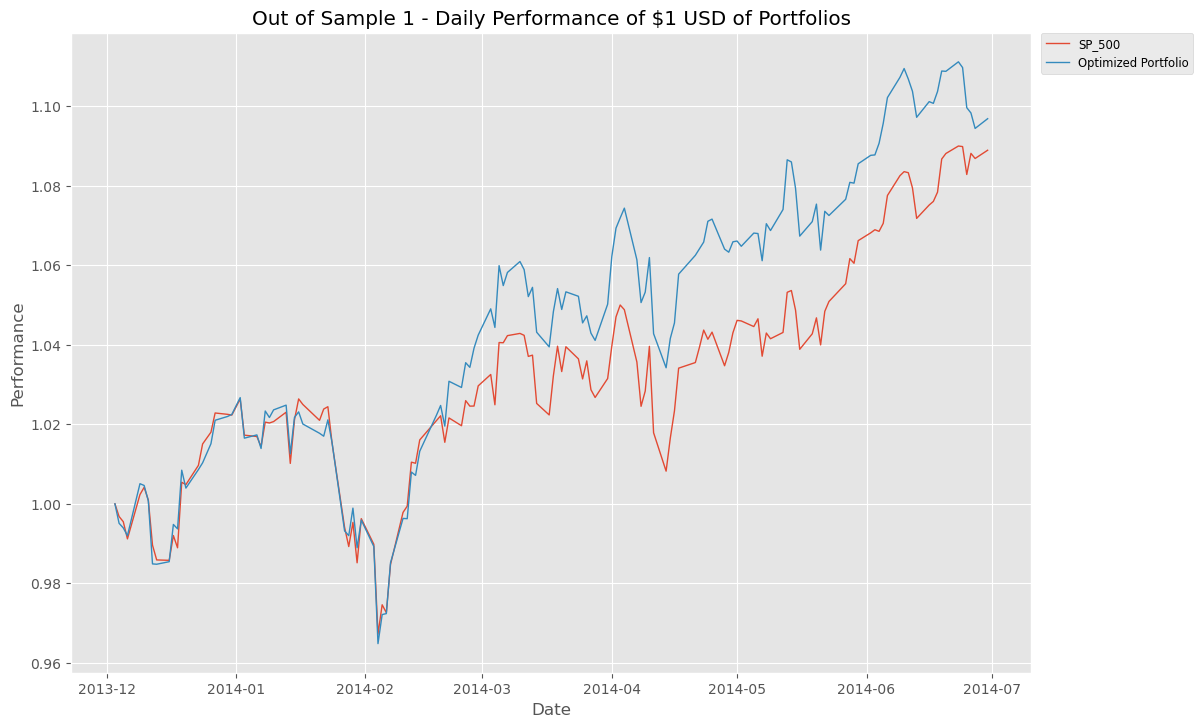

In [ ]:
# OUT OF SAMPLE HISTORICAL(OOS) PERFORMANCE

init = 1        #Initial Common Value (Can be thought of Initial Investment of $1 USD in each stock)

oos1_new_returns = pd.DataFrame(np.ones((len(oos1_daily_data),len(oos1_daily_data.columns))), index = oos1_daily_data.index, columns = oos1_daily_data.columns)
for j in range(1,len(oos1_daily_data.index)):
    oos1_new_returns.iloc[j] = oos1_new_returns.iloc[j-1]*(oos1_daily_data.iloc[j-1][oos1_daily_data.columns])
oos1_new_performance = pd.DataFrame(np.ones((len(oos1_daily_data),2)), index = oos1_daily_data.index, columns = oos1_daily_data.columns[-2:])
for j in range(1,len(oos1_daily_data.index)):
    oos1_new_performance.iloc[j] = oos1_new_performance.iloc[j-1]*(oos1_daily_data.iloc[j-1][oos1_daily_data.columns[-2:]]+1)
plt.style.use('ggplot')
fig = plt.figure(figsize=(12,8), dpi=100)
axes = fig.add_axes([0.1, 0.1, 0.8, 0.8])   # left, bottom, width, height (range 0 to 1)

# Plot on that set of axes
for i in range(0,len(oos1_daily_data.columns[-2:])):
        axes.plot(oos1_new_performance.index, oos1_new_performance.iloc[:,i], linewidth=1)

#axes.set_prop_cycle(cycler)
axes.set_xlabel('Date')
axes.set_ylabel('Performance')
axes.set_title('Out of Sample 1 - Daily Performance of $1 USD of Portfolios')
axes.legend(oos1_daily_data.columns[-2:], bbox_to_anchor=(1.01, 1), loc='upper left', borderaxespad=0, fontsize='small')

plt.show()


In [ ]:
# Fama French Monthly Data using getFamaFrenchFactors module
oos_1_ff3_monthly = gff.famaFrench3Factor(frequency='m')
oos_1_ff3_monthly.rename(columns={"date_ff_factors": 'Date'}, inplace=True)
oos_1_ff3_monthly.set_index('Date', inplace=True)
oos_1_ff3_monthly.index = oos_1_ff3_monthly.index.to_period('M').to_timestamp('D')
# Keeping Only the Dates in the monthly_data
oos_1_ff3_monthly = oos_1_ff3_monthly.loc[oos1_monthly_data.index]

In [ ]:
# Create an empty DataFrame to store the OOS 1 Stock Betas
oos1_stock_betas = pd.DataFrame()

# Iterate over the tickers list
for col in oos1_monthly_data.columns[:]:
    # Set the dependent variable (Return of stock i)
    y = oos1_monthly_data[col]

    # Set the independent variables (Fama French 3 Factors)
    X = oos_1_ff3_monthly[['Mkt-RF','SMB','HML']]

    # Fit the multiple linear regression model
    model = LinearRegression()
    model.fit(X, y)

    # Store the results in the DataFrame
    oos1_stock_betas[col] = [model.intercept_] + list(model.coef_)
oos1_stock_betas = oos1_stock_betas.T
oos1_stock_betas.columns = ['Intercept','Mkt-RF','SMB','HML']

In [ ]:
#Stock Prices on the Day of OOS1 Optimization(Rebalancing)
oos1_stock_price = pd.DataFrame(yf.download(tickers,start=o1_start,end=o1_end,interval='1d')['Adj Close'])
oos1_stock_price = oos1_stock_price[-1:].tz_localize(None)
#Dictionary of Stock Prices on the Day of OOS1 Optimization(Rebalancing)
oos1_s_price = {}
oos1_s_keys = list(tickers)
oos1_s_values =  list(oos1_stock_price.iloc[0])
for key,value in zip(oos1_s_keys,oos1_s_values):
    oos1_s_price[key] = value

[*********************100%***********************]  445 of 445 completed


In [ ]:
#Transaction Costs on the Day of OOS1 Optimization(Rebalancing)
random.seed(2)
oos1_t_cost = {}
oos1_keys       = list(tickers)
#values     = [.15 for i in range(len(keys))]
oos1_values = list(random.uniform(0,.08) for i in range(len(tickers)))
for key,value in zip(oos1_keys,oos1_values):
    oos1_t_cost[key] = value

In [ ]:
# TARGET FACTOR BETAS
mkt_opt = .90                                                               # PORTFOLIO TARGET MKT BETA
smb_opt = .10                                                               # PORTFOLIO TARGET SMB BETA
hml_opt = 0.05                                                              # PORTFOLIO TARGET HML BETA
oos1_base_weights = pd.DataFrame(weights['New Weights'].T)
B = 1000000                                                                 # BUDGET

In [ ]:
# OPTIMIZATION MODEL

oos1_index = LpProblem('Index', LpMinimize)

# Decision Variables

oos1_wei = LpVariable.dicts('Weight',tickers,lowBound=0)             # Weights for stock i in the optimal portfolio
oos1_aux = LpVariable.dicts('Y',tickers,lowBound=0)                  # Absolute value of change for stock i from base weights
oos1_err = LpVariable.dicts('Error', oos1_monthly_data.index, lowBound=0) # Error term for portfolio
oos1_binary = LpVariable.dicts('bin',tickers,cat=LpBinary)           # Used if we want to limit the # of stocks we want to have in optimal portfolio
oos1_tr_cost = LpVariable.dicts('Transaction_Cost',tickers,lowBound=0)             # Weights for stock i in the optimal portfolio


#Objective Function - Minimize the error term
oos1_index +=  lpSum(oos1_err[t] for t in oos1_monthly_data.index)

# Constraint: Weights sum to 1
oos1_index += lpSum([oos1_wei[i] for i in tickers]) == 1

# Constraint: Absolute value of change in weights from base weigths
for i in tickers:
    oos1_index += oos1_aux[i] >= oos1_base_weights.loc[i]  - oos1_wei[i]
    oos1_index += oos1_aux[i] >= oos1_wei[i] - oos1_base_weights.loc[i]
oos1_index += lpSum(oos1_aux[i] for i in tickers) <= 1
# Constraint: Error term
for t in oos1_monthly_data.index:
    oos1_index += lpSum(oos1_wei[i]*(oos1_monthly_data.loc[t,i]-oos_1_ff3_monthly.loc[t,'RF']) for i in tickers) - oos1_err[t] <= (mkt_opt*oos_1_ff3_monthly.loc[t,'Mkt-RF']+smb_opt*oos_1_ff3_monthly.loc[t,'SMB']+hml_opt*oos_1_ff3_monthly.loc[t,'HML'])
    oos1_index += lpSum(oos1_wei[i]*(oos1_monthly_data.loc[t,i]-oos_1_ff3_monthly.loc[t,'RF']) for i in tickers) + oos1_err[t] >= (mkt_opt*oos_1_ff3_monthly.loc[t,'Mkt-RF']+smb_opt*oos_1_ff3_monthly.loc[t,'SMB']+hml_opt*oos_1_ff3_monthly.loc[t,'HML'])

# Transaction Costs
for i in tickers:
   oos1_index += lpSum(oos1_aux[i] * B * oos1_t_cost[i]/oos1_s_price[i]) == oos1_tr_cost[i]
oos1_index += lpSum(oos1_tr_cost[i] for i in tickers) <= 20000
# Limit # of stocks in Optimal Portfolio
for i in tickers: # Forces weight of stock i to be less than binary value of stock i. If stock is not selected binary variable is 0 which then forces weight of stock i to be in the optimal portfolio to be 0.
    oos1_index += oos1_wei[i] <= oos1_binary[i]

oos1_index += lpSum(oos1_binary[i] for i in tickers) <= 100


oos1_index.solve()

Welcome to the CBC MILP Solver 
Version: 2.10.3 
Build Date: Dec 15 2019 

command line - /Users/asimturk/opt/anaconda3/lib/python3.9/site-packages/pulp/apis/../solverdir/cbc/osx/64/cbc /var/folders/3h/z7y93q3521g6rhyrtbcqb9ym0000gn/T/f25fc2670a144a4aa569be232176837a-pulp.mps timeMode elapsed branch printingOptions all solution /var/folders/3h/z7y93q3521g6rhyrtbcqb9ym0000gn/T/f25fc2670a144a4aa569be232176837a-pulp.sol (default strategy 1)
At line 2 NAME          MODEL
At line 3 ROWS
At line 1861 COLUMNS
At line 40210 RHS
At line 42067 BOUNDS
At line 42513 ENDATA
Problem MODEL has 1856 rows, 1816 columns and 37422 elements
Coin0008I MODEL read with 0 errors
Option for timeMode changed from cpu to elapsed
Continuous objective value is 0 - 0.05 seconds
Cgl0003I 0 fixed, 0 tightened bounds, 37 strengthened rows, 0 substitutions
Cgl0004I processed model has 1003 rows, 1371 columns (445 integer (445 of which binary)) and 35753 elements
Cbc0038I Initial state - 37 integers unsatisfied sum - 0.

1

In [ ]:
oos1_tr_costt = pd.DataFrame([v.varValue for v in oos1_index.variables() if str(v.name)[0] == 'T'], index = [str(v.name) for v in oos1_index.variables() if str(v.name)[0] == 'T'] , columns = ['Optimal'])
oos1_tr_costt.sum()

Optimal    255.851389
dtype: float64

In [ ]:
oos1_weii = pd.DataFrame([v.varValue for v in oos1_index.variables() if str(v.name)[0] == 'W'], index = [str(v.name) for v in oos1_index.variables() if str(v.name)[0] == 'W'] , columns = ['Optimal'])
oos1_weii.sum()

Optimal    1.0
dtype: float64

In [ ]:
oos1_auxx = pd.DataFrame([v.varValue for v in oos1_index.variables() if str(v.name)[0] == 'Y'], index = [str(v.name) for v in oos1_index.variables() if str(v.name)[0] == 'Y'] , columns = ['Optimal'])
oos1_auxx.sum()

Optimal    0.715251
dtype: float64

In [ ]:
oos1_errr = pd.DataFrame([v.varValue for v in oos1_index.variables() if str(v.name)[0] == 'E'], index = [str(v.name) for v in oos1_index.variables() if str(v.name)[0] == 'E'] , columns = ['Optimal'])
oos1_errr.sum()

Optimal    0.0
dtype: float64

In [ ]:
# Check if Binary Values Constraint works
oos1_binary_v = pd.DataFrame([v.varValue for v in oos1_index.variables() if v.varValue != 0 and str(v.name)[0] == 'b'], index = [str(v.name) for v in oos1_index.variables() if v.varValue != 0 and str(v.name)[0] == 'b'] , columns = ['Optimal'])
oos1_binary_v.sum()

Optimal    51.0
dtype: float64

In [ ]:
# Weights in Optimal Portfolio
oos1_opt_weights = pd.DataFrame([v.varValue for v in oos1_index.variables() if v.varValue != 0 and str(v.name)[0] == 'W'], index = [str(v.name) for v in oos1_index.variables() if v.varValue != 0 and str(v.name)[0] == 'W'] , columns = ['Optimal'])
oos1_opt_weights.style.format('{:,.2%}'.format)

In [ ]:
# WEIGHTS AND RETURNS OLD PORTFOLIO VS. NEW PORTFOLIO

oos1_weights_new = pd.DataFrame([v.varValue for v in oos1_index.variables() if str(v.name[0]) == 'W'], index = [str(v.name).split('_')[1] for v in oos1_index.variables() if str(v.name[0]) == 'W'] , columns = ['New Weights'])
oos1_weights = pd.DataFrame(np.zeros((len(oos1_monthly_data.columns[:-2]),3)), index=oos1_monthly_data.columns[:-2], columns=['PORTFOLIO Weights','Difference','New Weights'])
for t in oos1_monthly_data.columns[:-2]:
    oos1_weights.loc[t][0] = round(oos1_base_weights.loc[t],4)
    oos1_weights.loc[t][1] = round(oos1_weights_new.loc[t][0]-oos1_base_weights.loc[t][0],4)
    oos1_weights.loc[t][2] = oos1_weights_new.loc[t]
oos1_weights

,PORTFOLIO Weights,Difference,New Weights
A,0.0000,0.000,0.000000
AAL,0.0000,0.000,0.000000
AAP,0.0000,0.000,0.000000
AAPL,0.0000,0.000,0.000000
ABC,0.0000,0.000,0.000000
...,...,...,...
XRAY,0.0000,0.000,0.000000
YUM,0.0000,0.000,0.000000
ZBH,0.0131,-0.003,0.010139
ZBRA,0.0000,0.000,0.000000


In [ ]:
# CHECK PORTFOLIO BETAS

oos1_port_returns = pd.DataFrame(np.zeros((len(oos1_monthly_data.index),2)), index=oos1_monthly_data.index, columns=["Portfolio","Optimization"])
for j in oos1_port_returns.index:
    oos1_port_returns.loc[j]["Portfolio"] = oos1_monthly_data.loc[j]['Optimized Portfolio']
    oos1_port_returns.loc[j]['Optimization'] = oos1_monthly_data.loc[j,:oos1_monthly_data.columns[-3]].dot(oos1_weights['New Weights'])
oos1_port_returns = oos1_port_returns.merge(oos_1_ff3_monthly[['Mkt-RF','SMB','HML']], left_index=True, right_index=True)

# Create an empty DataFrame to store the Portfolio Beta
oos1_port_betas = pd.DataFrame(np.zeros((3,4)), index=oos_1_ff3_monthly.columns[0:3], columns=["Portfolio", "Target", "Optimization", "Abs. Diff"])

oos1_port_betas["Target"] = [mkt_opt, smb_opt, hml_opt]

# Set the independent variables (Fama French 3 Factors)
X = oos1_port_returns[['Mkt-RF','SMB','HML']]
# Set the dependent variable (Return of Portfolio)
Y = oos1_port_returns['Portfolio']
# Fit the multiple linear regression model
regr = LinearRegression()
regr.fit(X,Y)
oos1_port_betas['Portfolio'] = regr.coef_

# Set the dependent variable (Return of Portfolio)
Y = oos1_port_returns['Optimization']
# Fit the multiple linear regression model
regr = LinearRegression()
regr.fit(X,Y)
oos1_port_betas['Optimization'] = regr.coef_

# Abs Difference between Target Betas & Optimal Portfolio Betas
oos1_port_betas["Abs. Diff"] = round(abs(oos1_port_betas['Optimization'] - oos1_port_betas["Target"]),4)
oos1_port_betas

,Portfolio,Target,Optimization,Abs. Diff
Mkt-RF,0.931266,0.90,0.899397,0.0006
SMB,-0.016273,0.10,0.100638,0.0006
HML,0.095849,0.05,0.050853,0.0009


## OOS_2 START

In [ ]:
# OUT OF SAMPLE (OOS2) HISTORICAL MONTHLY DATA (**After OOS1 Optimization**)
o2_start = '2011-12-01'
o2_end   = '2015-01-01'
# OOS 1 Monthly Returns for Stocks in the List
oos2_monthly_data = yf.download(tickers,start=o2_start,end=o2_end,interval='1mo')
# Turn Adj Close prices into pct returns
oos2_monthly_data = oos2_monthly_data['Adj Close'].pct_change().dropna()
#Reformat Date Index
oos2_monthly_data = oos2_monthly_data.tz_localize(None)
#Adding SP_500 data
oos2_spy = pd.DataFrame(yf.download('^GSPC',start=o2_start,end=o2_end,interval='1mo')['Adj Close'].pct_change())
oos2_spy = oos2_spy.drop(oos2_spy.index[0]).tz_localize(None)
oos2_monthly_data['SP_500'] = oos2_spy['Adj Close']
#Create a Column of Returns for Portfolio Returns
#oos1_monthly_data['Portfolio'] = ''
# Multiply weight of stock i and return of stock i to get Portfolio Returns
#for i in range(len(oos1_monthly_data.index)):
#    oos1_monthly_data.iloc[i,-1] = oos1_monthly_data.iloc[i,:-1].dot(base_w['Weight'])
#Create a Column of Returns for Optimal Portfolio Returns
oos2_monthly_data['Optimized Portfolio'] = ''
# Multiply weight of stock i and return of stock i to get Optimal Portfolio Returns
for i in range(len(oos2_monthly_data.index)):
    oos2_monthly_data.iloc[i,-1] = oos2_monthly_data.iloc[i,:-2].dot(oos1_weights['New Weights'])

[*********************100%***********************]  445 of 445 completed
[*********************100%***********************]  1 of 1 completed


In [ ]:
# OUT OF SAMPLE (OOS2) HISTORICAL DAILY DATA (**After OOS1 Optimization**)
o2_start_d = '2014-06-30'
o2_end_d   = '2015-01-01'
# OOS 1 DAILY Returns for Stocks in the List
oos2_daily_data = yf.download(tickers,start=o2_start_d,end=o2_end_d,interval='1d')
# Turn Adj Close prices into pct returns
oos2_daily_data = oos2_daily_data['Adj Close'].pct_change().dropna()
#Reformat Date Index
oos2_daily_data = oos2_daily_data.tz_localize(None)
#Adding SP_500 data
oos2_spy_d = pd.DataFrame(yf.download('^GSPC',start=o2_start_d,end=o2_end_d,interval='1d')['Adj Close'].pct_change())
oos2_spy_d = oos2_spy_d.drop(oos2_spy_d.index[0]).tz_localize(None)
oos2_daily_data['SP_500'] = oos2_spy_d['Adj Close']
#Create a Column of Returns for Portfolio Returns
#oos1_monthly_data['Portfolio'] = ''
# Multiply weight of stock i and return of stock i to get Portfolio Returns
#for i in range(len(oos1_monthly_data.index)):
#    oos1_monthly_data.iloc[i,-1] = oos1_monthly_data.iloc[i,:-1].dot(base_w['Weight'])
#Create a Column of Returns for Optimal Portfolio Returns
oos2_daily_data['Optimized Portfolio'] = ''
# Multiply weight of stock i and return of stock i to get Optimal Portfolio Returns
for i in range(len(oos2_daily_data.index)):
    oos2_daily_data.iloc[i,-1] = oos2_daily_data.iloc[i,:-2].dot(oos1_weights['New Weights'])


[*********************100%***********************]  445 of 445 completed
[*********************100%***********************]  1 of 1 completed


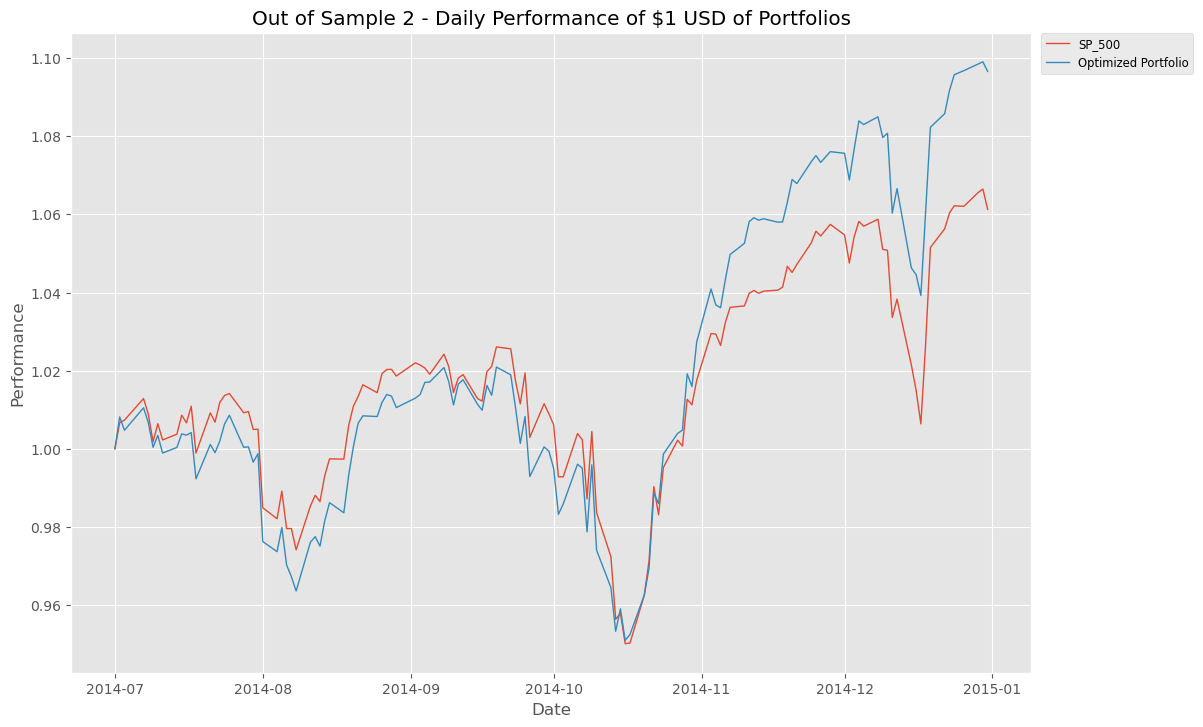

In [ ]:
# OUT OF SAMPLE 2 HISTORICAL(OOS2) PERFORMANCE

init = 1        #Initial Common Value (Can be thought of Initial Investment of $1 USD in each stock)

oos2_new_returns = pd.DataFrame(np.ones((len(oos2_daily_data),len(oos2_daily_data.columns))), index = oos2_daily_data.index, columns = oos2_daily_data.columns)
for j in range(1,len(oos2_daily_data.index)):
    oos2_new_returns.iloc[j] = oos2_new_returns.iloc[j-1]*(oos2_daily_data.iloc[j-1][oos2_daily_data.columns])
oos2_new_returns = pd.DataFrame(np.ones((len(oos2_daily_data),2)), index = oos2_daily_data.index, columns = oos2_daily_data.columns[-2:])
for j in range(1,len(oos2_daily_data.index)):
    oos2_new_returns.iloc[j] = oos2_new_returns.iloc[j-1]*(oos2_daily_data.iloc[j-1][oos2_daily_data.columns[-2:]]+1)
plt.style.use('ggplot')
fig = plt.figure(figsize=(12,8), dpi=100)
axes = fig.add_axes([0.1, 0.1, 0.8, 0.8])   # left, bottom, width, height (range 0 to 1)

# Plot on that set of axes
for i in range(0,len(oos2_daily_data.columns[-2:])):
        axes.plot(oos2_new_returns.index, oos2_new_returns.iloc[:,i], linewidth=1)

#axes.set_prop_cycle(cycler)
axes.set_xlabel('Date')
axes.set_ylabel('Performance')
axes.set_title('Out of Sample 2 - Daily Performance of $1 USD of Portfolios')
axes.legend(oos2_daily_data.columns[-2:], bbox_to_anchor=(1.01, 1), loc='upper left', borderaxespad=0, fontsize='small')

plt.show()


In [ ]:
# Fama French Monthly Data using getFamaFrenchFactors module
oos_2_ff3_monthly = gff.famaFrench3Factor(frequency='m')
oos_2_ff3_monthly.rename(columns={"date_ff_factors": 'Date'}, inplace=True)
oos_2_ff3_monthly.set_index('Date', inplace=True)
oos_2_ff3_monthly.index = oos_2_ff3_monthly.index.to_period('M').to_timestamp('D')
# Keeping Only the Dates in the monthly_data
oos_2_ff3_monthly = oos_2_ff3_monthly.loc[oos2_monthly_data.index]

In [ ]:
# Create an empty DataFrame to store the OOS 2 Stock Betas
oos2_stock_betas = pd.DataFrame()

# Iterate over the tickers list
for col in oos2_monthly_data.columns[:]:
    # Set the dependent variable (Return of stock i)
    y = oos2_monthly_data[col]

    # Set the independent variables (Fama French 3 Factors)
    X = oos_2_ff3_monthly[['Mkt-RF','SMB','HML']]

    # Fit the multiple linear regression model
    model = LinearRegression()
    model.fit(X, y)

    # Store the results in the DataFrame
    oos2_stock_betas[col] = [model.intercept_] + list(model.coef_)
oos2_stock_betas = oos2_stock_betas.T
oos2_stock_betas.columns = ['Intercept','Mkt-RF','SMB','HML']

In [ ]:
# TARGET FACTOR BETAS
mkt_opt = 0.90                                                               # PORTFOLIO TARGET MKT BETA
smb_opt = 0.10                                                               # PORTFOLIO TARGET SMB BETA
hml_opt = 0.05                                                              # PORTFOLIO TARGET HML BETA
oos2_base_weights = pd.DataFrame(oos1_weights['New Weights'].T)
B = 1000000

In [ ]:
#Stock Prices on the Day of OOS2 Optimization(Rebalancing)
oos2_stock_price = pd.DataFrame(yf.download(tickers,start=o2_start,end=o2_end,interval='1d')['Adj Close'])
oos2_stock_price = oos2_stock_price[-1:].tz_localize(None)
#Dictionary of Stock Prices on the Day of OOS2 Optimization(Rebalancing)
oos2_s_price = {}
oos2_s_keys = list(tickers)
oos2_s_values =  list(oos2_stock_price.iloc[0])
for key,value in zip(oos2_s_keys,oos2_s_values):
    oos2_s_price[key] = value

[*********************100%***********************]  445 of 445 completed


In [ ]:
#Transaction Costs on the Day of OOS2 Optimization(Rebalancing)
random.seed(3)
oos2_t_cost = {}
oos2_keys       = list(tickers)
#values     = [.15 for i in range(len(keys))]
oos2_values = list(random.uniform(0,.08) for i in range(len(tickers)))
for key,value in zip(oos2_keys,oos2_values):
    oos2_t_cost[key] = value

In [ ]:
# OPTIMIZATION MODEL

oos2_index = LpProblem('Index', LpMinimize)

# Decision Variables

oos2_wei = LpVariable.dicts('Weight',tickers,lowBound=0)             # Weights for stock i in the optimal portfolio
oos2_aux = LpVariable.dicts('Y',tickers,lowBound=0)                  # Absolute value of change for stock i from base weights
oos2_err = LpVariable.dicts('Error', oos2_monthly_data.index, lowBound=0) # Error term for portfolio
oos2_binary = LpVariable.dicts('bin',tickers,cat=LpBinary)           # Used if we want to limit the # of stocks we want to have in optimal portfolio
oos2_tr_cost = LpVariable.dicts('Transaction_Cost',tickers,lowBound=0)             # Weights for stock i in the optimal portfolio


#Objective Function - Minimize the error term
oos2_index +=  lpSum(oos2_err[t] for t in oos2_monthly_data.index)

# Constraint: Weights sum to 1
oos2_index += lpSum([oos2_wei[i] for i in tickers]) == 1

# Constraint: Absolute value of change in weights from base weigths
for i in tickers:
    oos2_index += oos2_aux[i] >= oos2_base_weights.loc[i]  - oos2_wei[i]
    oos2_index += oos2_aux[i] >= oos2_wei[i] - oos2_base_weights.loc[i]
oos2_index += lpSum(oos2_aux[i] for i in tickers) <= 1

# Constraint: Error term
for t in oos2_monthly_data.index:
    oos2_index += lpSum(oos2_wei[i]*(oos2_monthly_data.loc[t,i]-oos_2_ff3_monthly.loc[t,'RF']) for i in tickers) - oos2_err[t] <= (mkt_opt*oos_2_ff3_monthly.loc[t,'Mkt-RF']+smb_opt*oos_2_ff3_monthly.loc[t,'SMB']+hml_opt*oos_2_ff3_monthly.loc[t,'HML'])
    oos2_index += lpSum(oos2_wei[i]*(oos2_monthly_data.loc[t,i]-oos_2_ff3_monthly.loc[t,'RF']) for i in tickers) + oos2_err[t] >= (mkt_opt*oos_2_ff3_monthly.loc[t,'Mkt-RF']+smb_opt*oos_2_ff3_monthly.loc[t,'SMB']+hml_opt*oos_2_ff3_monthly.loc[t,'HML'])

# Transaction Costs
for i in tickers:
    oos2_index += lpSum(oos2_aux[i] * B * oos2_t_cost[i]/oos2_s_price[i]) == oos2_tr_cost[i]
oos2_index += lpSum(oos2_tr_cost[i] for i in tickers) <= 20000
# Limit # of stocks in Optimal Portfolio
for i in tickers: # Forces weight of stock i to be less than binary value of stock i. If stock is not selected binary variable is 0 which then forces weight of stock i to be in the optimal portfolio to be 0.
    oos2_index += oos2_wei[i] <= oos2_binary[i]

oos2_index += lpSum(oos2_binary[i] for i in tickers) <= 100

oos2_index.solve()

Welcome to the CBC MILP Solver 
Version: 2.10.3 
Build Date: Dec 15 2019 

command line - /Users/asimturk/opt/anaconda3/lib/python3.9/site-packages/pulp/apis/../solverdir/cbc/osx/64/cbc /var/folders/3h/z7y93q3521g6rhyrtbcqb9ym0000gn/T/4c2d64e31db244e4a3a6d75282ab1f3e-pulp.mps timeMode elapsed branch printingOptions all solution /var/folders/3h/z7y93q3521g6rhyrtbcqb9ym0000gn/T/4c2d64e31db244e4a3a6d75282ab1f3e-pulp.sol (default strategy 1)
At line 2 NAME          MODEL
At line 3 ROWS
At line 1861 COLUMNS
At line 40210 RHS
At line 42067 BOUNDS
At line 42513 ENDATA
Problem MODEL has 1856 rows, 1816 columns and 37422 elements
Coin0008I MODEL read with 0 errors
Option for timeMode changed from cpu to elapsed
Continuous objective value is 0 - 0.04 seconds
Cgl0003I 0 fixed, 0 tightened bounds, 49 strengthened rows, 0 substitutions
Cgl0004I processed model has 1015 rows, 1371 columns (445 integer (445 of which binary)) and 35789 elements
Cbc0038I Initial state - 37 integers unsatisfied sum - 0.

1

In [ ]:
oos2_tr_costt = pd.DataFrame([v.varValue for v in oos2_index.variables() if str(v.name)[0] == 'T'], index = [str(v.name) for v in oos2_index.variables() if str(v.name)[0] == 'T'] , columns = ['Optimal'])
oos2_tr_costt.sum()

Optimal    141.390148
dtype: float64

In [ ]:
oos2_auxx = pd.DataFrame([v.varValue for v in oos2_index.variables() if str(v.name)[0] == 'Y'], index = [str(v.name) for v in oos2_index.variables() if str(v.name)[0] == 'Y'] , columns = ['Optimal'])
oos2_auxx.sum()

Optimal    0.426668
dtype: float64

In [ ]:
oos2_errr = pd.DataFrame([v.varValue for v in oos2_index.variables() if str(v.name)[0] == 'E'], index = [str(v.name) for v in oos2_index.variables() if str(v.name)[0] == 'E'] , columns = ['Optimal'])
oos2_errr.sum()

Optimal    0.0
dtype: float64

In [ ]:
# Check if Binary Values Constraint works
oos2_binary_v = pd.DataFrame([v.varValue for v in oos2_index.variables() if v.varValue != 0 and str(v.name)[0] == 'b'], index = [str(v.name) for v in oos2_index.variables() if v.varValue != 0 and str(v.name)[0] == 'b'] , columns = ['Optimal'])
oos2_binary_v.sum()

Optimal    63.0
dtype: float64

In [ ]:
# Weights in Optimal Portfolio
oos2_opt_weights = pd.DataFrame([v.varValue for v in oos2_index.variables() if v.varValue != 0 and str(v.name)[0] == 'W'], index = [str(v.name) for v in oos2_index.variables() if v.varValue != 0 and str(v.name)[0] == 'W'] , columns = ['Optimal'])
oos2_opt_weights.style.format('{:,.2%}'.format)

,Optimal
Weight_ADBE,0.73%
Weight_ALB,3.27%
Weight_AMZN,1.15%
Weight_APA,0.48%
Weight_ATO,0.90%
Weight_AVB,0.34%
Weight_BKR,1.41%
Weight_BMY,0.40%
Weight_CAT,0.31%
Weight_CHTR,0.17%


In [ ]:
# WEIGHTS AND RETURNS OLD PORTFOLIO VS. NEW PORTFOLIO

oos2_weights_new = pd.DataFrame([v.varValue for v in oos2_index.variables() if str(v.name[0]) == 'W'], index = [str(v.name).split('_')[1] for v in oos2_index.variables() if str(v.name[0]) == 'W'] , columns = ['New Weights'])
oos2_weights = pd.DataFrame(np.zeros((len(oos2_monthly_data.columns[:-2]),3)), index=oos2_monthly_data.columns[:-2], columns=['PORTFOLIO Weights','Difference','New Weights'])
for t in oos2_monthly_data.columns[:-2]:
    oos2_weights.loc[t][0] = round(oos2_base_weights.loc[t],4)
    oos2_weights.loc[t][1] = round(oos2_weights_new.loc[t][0]-oos2_base_weights.loc[t][0],4)
    oos2_weights.loc[t][2] = oos2_weights_new.loc[t]
oos2_weights

,PORTFOLIO Weights,Difference,New Weights
A,0.0000,0.0000,0.0
AAL,0.0000,0.0000,0.0
AAP,0.0000,0.0000,0.0
AAPL,0.0000,0.0000,0.0
ABC,0.0000,0.0000,0.0
...,...,...,...
XRAY,0.0000,0.0000,0.0
YUM,0.0000,0.0000,0.0
ZBH,0.0101,-0.0101,0.0
ZBRA,0.0000,0.0000,0.0


In [ ]:
# CHECK PORTFOLIO BETAS

oos2_port_returns = pd.DataFrame(np.zeros((len(oos2_monthly_data.index),2)), index=oos2_monthly_data.index, columns=["Portfolio","Optimization"])
for j in oos2_port_returns.index:
    oos2_port_returns.loc[j]["Portfolio"] = oos2_monthly_data.loc[j]['Optimized Portfolio']
    oos2_port_returns.loc[j]['Optimization'] = oos2_monthly_data.loc[j,:oos2_monthly_data.columns[-3]].dot(oos2_weights['New Weights'])
oos2_port_returns = oos2_port_returns.merge(oos_2_ff3_monthly[['Mkt-RF','SMB','HML']], left_index=True, right_index=True)

# Create an empty DataFrame to store the Portfolio Beta
oos2_port_betas = pd.DataFrame(np.zeros((3,4)), index=oos_2_ff3_monthly.columns[0:3], columns=["Portfolio", "Target", "Optimization", "Abs. Diff"])

oos2_port_betas["Target"] = [mkt_opt, smb_opt, hml_opt]

# Set the independent variables (Fama French 3 Factors)
X = oos2_port_returns[['Mkt-RF','SMB','HML']]
# Set the dependent variable (Return of Portfolio)
Y = oos2_port_returns['Portfolio']
# Fit the multiple linear regression model
regr = LinearRegression()
regr.fit(X,Y)
oos2_port_betas['Portfolio'] = regr.coef_

# Set the dependent variable (Return of Portfolio)
Y = oos2_port_returns['Optimization']
# Fit the multiple linear regression model
regr = LinearRegression()
regr.fit(X,Y)
oos2_port_betas['Optimization'] = regr.coef_

# Abs Difference between Target Betas & Optimal Portfolio Betas
oos2_port_betas["Abs. Diff"] = round(abs(oos2_port_betas['Optimization'] - oos2_port_betas["Target"]),4)
oos2_port_betas

,Portfolio,Target,Optimization,Abs. Diff
Mkt-RF,0.891621,0.90,0.899465,0.0005
SMB,0.140625,0.10,0.100429,0.0004
HML,-0.019838,0.05,0.050785,0.0008


OOS_3 START

In [ ]:
# OUT OF SAMPLE (OOS3) HISTORICAL MONTHLY DATA (**After OOS2 Optimization**)
o3_start = '2012-06-01'
o3_end   = '2015-07-01'
# OOS 1 Monthly Returns for Stocks in the List
oos3_monthly_data = yf.download(tickers,start=o3_start,end=o3_end,interval='1mo')
# Turn Adj Close prices into pct returns
oos3_monthly_data = oos3_monthly_data['Adj Close'].pct_change().dropna()
#Reformat Date Index
oos3_monthly_data = oos3_monthly_data.tz_localize(None)
#Adding SP_500 data
oos3_spy = pd.DataFrame(yf.download('^GSPC',start=o3_start,end=o3_end,interval='1mo')['Adj Close'].pct_change())
oos3_spy = oos3_spy.drop(oos3_spy.index[0]).tz_localize(None)
oos3_monthly_data['SP_500'] = oos3_spy['Adj Close']
#Create a Column of Returns for Portfolio Returns
#oos1_monthly_data['Portfolio'] = ''
# Multiply weight of stock i and return of stock i to get Portfolio Returns
#for i in range(len(oos1_monthly_data.index)):
#    oos1_monthly_data.iloc[i,-1] = oos1_monthly_data.iloc[i,:-1].dot(base_w['Weight'])
#Create a Column of Returns for Optimal Portfolio Returns
oos3_monthly_data['Optimized Portfolio'] = ''
# Multiply weight of stock i and return of stock i to get Optimal Portfolio Returns
for i in range(len(oos3_monthly_data.index)):
    oos3_monthly_data.iloc[i,-1] = oos3_monthly_data.iloc[i,:-2].dot(oos2_weights['New Weights'])

[*********************100%***********************]  445 of 445 completed
[*********************100%***********************]  1 of 1 completed


In [ ]:
# OUT OF SAMPLE (OOS3) HISTORICAL DAILY DATA (**After OOS2 Optimization**)
o3_start_d = '2014-12-31'
o3_end_d   = '2015-07-01'
# OOS 1 DAILY Returns for Stocks in the List
oos3_daily_data = yf.download(tickers,start=o3_start_d,end=o3_end_d,interval='1d')
# Turn Adj Close prices into pct returns
oos3_daily_data = oos3_daily_data['Adj Close'].pct_change().dropna()
#Reformat Date Index
oos3_daily_data = oos3_daily_data.tz_localize(None)
#Adding SP_500 data
oos3_spy_d = pd.DataFrame(yf.download('^GSPC',start=o3_start_d,end=o3_end_d,interval='1d')['Adj Close'].pct_change())
oos3_spy_d = oos3_spy_d.drop(oos3_spy_d.index[0]).tz_localize(None)
oos3_daily_data['SP_500'] = oos3_spy_d['Adj Close']
#Create a Column of Returns for Portfolio Returns
#oos1_monthly_data['Portfolio'] = ''
# Multiply weight of stock i and return of stock i to get Portfolio Returns
#for i in range(len(oos1_monthly_data.index)):
#    oos1_monthly_data.iloc[i,-1] = oos1_monthly_data.iloc[i,:-1].dot(base_w['Weight'])
#Create a Column of Returns for Optimal Portfolio Returns
oos3_daily_data['Optimized Portfolio'] = ''
# Multiply weight of stock i and return of stock i to get Optimal Portfolio Returns
for i in range(len(oos3_daily_data.index)):
    oos3_daily_data.iloc[i,-1] = oos3_daily_data.iloc[i,:-2].dot(oos2_weights['New Weights'])


[*********************100%***********************]  445 of 445 completed
[*********************100%***********************]  1 of 1 completed


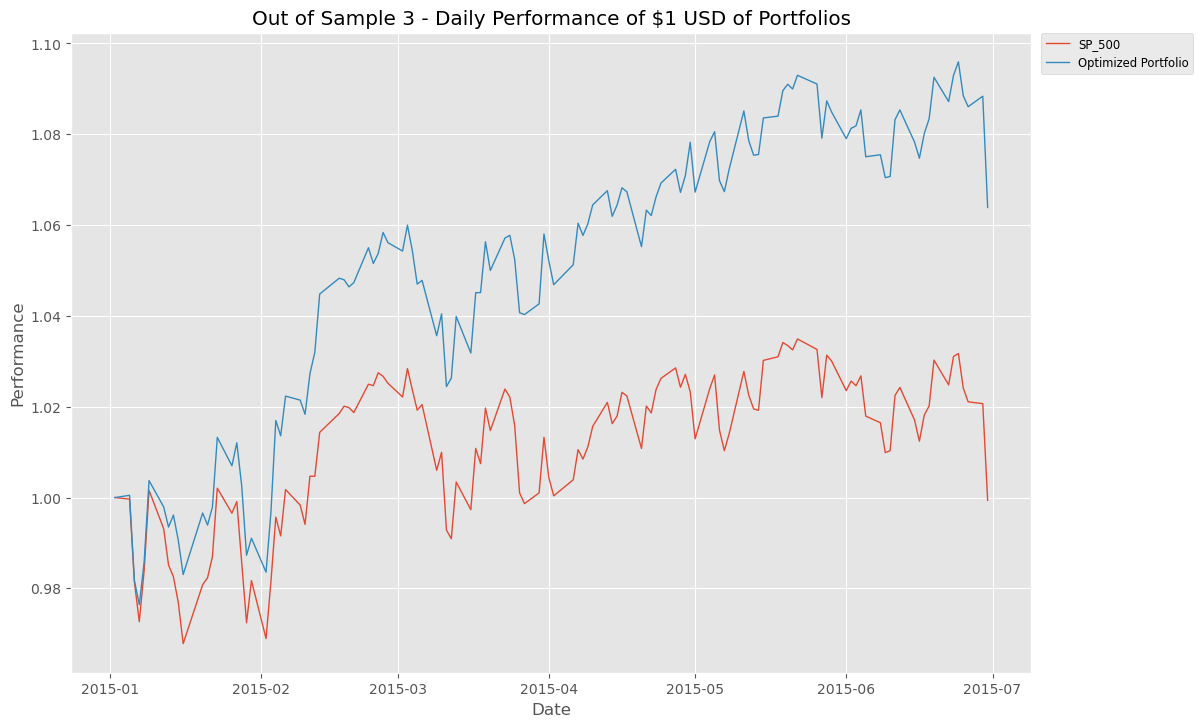

In [ ]:
# OUT OF SAMPLE 3 HISTORICAL(OOS3) PERFORMANCE

init = 1        #Initial Common Value (Can be thought of Initial Investment of $1 USD in each stock)

oos3_new_returns = pd.DataFrame(np.ones((len(oos3_daily_data),len(oos3_daily_data.columns))), index = oos3_daily_data.index, columns = oos3_daily_data.columns)
for j in range(1,len(oos3_daily_data.index)):
    oos3_new_returns.iloc[j] = oos3_new_returns.iloc[j-1]*(oos3_daily_data.iloc[j-1][oos3_daily_data.columns])
oos3_new_returns = pd.DataFrame(np.ones((len(oos3_daily_data),2)), index = oos3_daily_data.index, columns = oos3_daily_data.columns[-2:])
for j in range(1,len(oos3_daily_data.index)):
    oos3_new_returns.iloc[j] = oos3_new_returns.iloc[j-1]*(oos3_daily_data.iloc[j-1][oos3_daily_data.columns[-2:]]+1)
plt.style.use('ggplot')
fig = plt.figure(figsize=(12,8), dpi=100)
axes = fig.add_axes([0.1, 0.1, 0.8, 0.8])   # left, bottom, width, height (range 0 to 1)

# Plot on that set of axes
for i in range(0,len(oos3_daily_data.columns[-2:])):
        axes.plot(oos3_new_returns.index, oos3_new_returns.iloc[:,i], linewidth=1)

#axes.set_prop_cycle(cycler)
axes.set_xlabel('Date')
axes.set_ylabel('Performance')
axes.set_title('Out of Sample 3 - Daily Performance of $1 USD of Portfolios')
axes.legend(oos3_daily_data.columns[-2:], bbox_to_anchor=(1.01, 1), loc='upper left', borderaxespad=0, fontsize='small')

plt.show()


In [ ]:
# Fama French Monthly Data using getFamaFrenchFactors module
oos_3_ff3_monthly = gff.famaFrench3Factor(frequency='m')
oos_3_ff3_monthly.rename(columns={"date_ff_factors": 'Date'}, inplace=True)
oos_3_ff3_monthly.set_index('Date', inplace=True)
oos_3_ff3_monthly.index = oos_3_ff3_monthly.index.to_period('M').to_timestamp('D')
# Keeping Only the Dates in the monthly_data
oos_3_ff3_monthly = oos_3_ff3_monthly.loc[oos3_monthly_data.index]

In [ ]:
# Create an empty DataFrame to store the OOS 3 Stock Betas
oos3_stock_betas = pd.DataFrame()

# Iterate over the tickers list
for col in oos3_monthly_data.columns[:]:
    # Set the dependent variable (Return of stock i)
    y = oos3_monthly_data[col]

    # Set the independent variables (Fama French 3 Factors)
    X = oos_3_ff3_monthly[['Mkt-RF','SMB','HML']]

    # Fit the multiple linear regression model
    model = LinearRegression()
    model.fit(X, y)

    # Store the results in the DataFrame
    oos3_stock_betas[col] = [model.intercept_] + list(model.coef_)
oos3_stock_betas = oos3_stock_betas.T
oos3_stock_betas.columns = ['Intercept','Mkt-RF','SMB','HML']

/var/folders/3h/z7y93q3521g6rhyrtbcqb9ym0000gn/T/ipykernel_29336/589451657.py:17: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  oos3_stock_betas[col] = [model.intercept_] + list(model.coef_)
/var/folders/3h/z7y93q3521g6rhyrtbcqb9ym0000gn/T/ipykernel_29336/589451657.py:17: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  oos3_stock_betas[col] = [model.intercept_] + list(model.coef_)
/var/folders/3h/z7y93q3521g6rhyrtbcqb9ym0000gn/T/ipykernel_29336/589451657.py:17: PerformanceWarning: DataFrame is highly fragmented.  This is usually t

In [ ]:
# TARGET FACTOR BETAS
mkt_opt = 0.90                                                               # PORTFOLIO TARGET MKT BETA
smb_opt = 0.10                                                               # PORTFOLIO TARGET SMB BETA
hml_opt = 0.05                                                              # PORTFOLIO TARGET HML BETA
oos3_base_weights = pd.DataFrame(oos1_weights['New Weights'].T)
B = 1000000

In [ ]:
#Stock Prices on the Day of OOS3 Optimization(Rebalancing)
oos3_stock_price = pd.DataFrame(yf.download(tickers,start=o3_start,end=o3_end,interval='1d')['Adj Close'])
oos3_stock_price = oos3_stock_price[-1:].tz_localize(None)
#Dictionary of Stock Prices on the Day of OOS2 Optimization(Rebalancing)
oos3_s_price = {}
oos3_s_keys = list(tickers)
oos3_s_values =  list(oos3_stock_price.iloc[0])
for key,value in zip(oos3_s_keys,oos3_s_values):
    oos3_s_price[key] = value

[*********************100%***********************]  445 of 445 completed


In [ ]:
#Transaction Costs on the Day of OOS3 Optimization(Rebalancing)
random.seed(3)
oos3_t_cost = {}
oos3_keys       = list(tickers)
#values     = [.15 for i in range(len(keys))]
oos3_values = list(random.uniform(0,.08) for i in range(len(tickers)))
for key,value in zip(oos3_keys,oos3_values):
    oos3_t_cost[key] = value

In [ ]:
# OPTIMIZATION MODEL

oos3_index = LpProblem('Index', LpMinimize)

# Decision Variables

oos3_wei = LpVariable.dicts('Weight',tickers,lowBound=0)             # Weights for stock i in the optimal portfolio
oos3_aux = LpVariable.dicts('Y',tickers,lowBound=0)                  # Absolute value of change for stock i from base weights
oos3_err = LpVariable.dicts('Error', oos3_monthly_data.index, lowBound=0) # Error term for portfolio
oos3_binary = LpVariable.dicts('bin',tickers,cat=LpBinary)           # Used if we want to limit the # of stocks we want to have in optimal portfolio
oos3_tr_cost = LpVariable.dicts('Transaction_Cost',tickers,lowBound=0)             # Weights for stock i in the optimal portfolio


#Objective Function - Minimize the error term
oos3_index +=  lpSum(oos3_err[t] for t in oos3_monthly_data.index)

# Constraint: Weights sum to 1
oos3_index += lpSum([oos3_wei[i] for i in tickers]) == 1

# Constraint: Absolute value of change in weights from base weigths
for i in tickers:
    oos3_index += oos3_aux[i] >= oos3_base_weights.loc[i]  - oos3_wei[i]
    oos3_index += oos3_aux[i] >= oos3_wei[i] - oos3_base_weights.loc[i]
oos3_index += lpSum(oos3_aux[i] for i in tickers) <= 1

# Constraint: Error term
for t in oos3_monthly_data.index:
    oos3_index += lpSum(oos3_wei[i]*(oos3_monthly_data.loc[t,i]-oos_3_ff3_monthly.loc[t,'RF']) for i in tickers) - oos3_err[t] <= (mkt_opt*oos_3_ff3_monthly.loc[t,'Mkt-RF']+smb_opt*oos_3_ff3_monthly.loc[t,'SMB']+hml_opt*oos_3_ff3_monthly.loc[t,'HML'])
    oos3_index += lpSum(oos3_wei[i]*(oos3_monthly_data.loc[t,i]-oos_3_ff3_monthly.loc[t,'RF']) for i in tickers) + oos3_err[t] >= (mkt_opt*oos_3_ff3_monthly.loc[t,'Mkt-RF']+smb_opt*oos_3_ff3_monthly.loc[t,'SMB']+hml_opt*oos_3_ff3_monthly.loc[t,'HML'])

# Transaction Costs
for i in tickers:
    oos3_index += lpSum(oos3_aux[i] * B * oos3_t_cost[i]/oos3_s_price[i]) == oos3_tr_cost[i]
oos3_index += lpSum(oos3_tr_cost[i] for i in tickers) <= 20000
# Limit # of stocks in Optimal Portfolio
for i in tickers: # Forces weight of stock i to be less than binary value of stock i. If stock is not selected binary variable is 0 which then forces weight of stock i to be in the optimal portfolio to be 0.
    oos3_index += oos3_wei[i] <= oos3_binary[i]

oos3_index += lpSum(oos3_binary[i] for i in tickers) <= 100

oos3_index.solve()

Welcome to the CBC MILP Solver 
Version: 2.10.3 
Build Date: Dec 15 2019 

command line - /Users/asimturk/opt/anaconda3/lib/python3.9/site-packages/pulp/apis/../solverdir/cbc/osx/64/cbc /var/folders/3h/z7y93q3521g6rhyrtbcqb9ym0000gn/T/6770224905b7461e81c75bb96bb93f36-pulp.mps timeMode elapsed branch printingOptions all solution /var/folders/3h/z7y93q3521g6rhyrtbcqb9ym0000gn/T/6770224905b7461e81c75bb96bb93f36-pulp.sol (default strategy 1)
At line 2 NAME          MODEL
At line 3 ROWS
At line 1861 COLUMNS
At line 40216 RHS
At line 42073 BOUNDS
At line 42519 ENDATA
Problem MODEL has 1856 rows, 1816 columns and 37428 elements
Coin0008I MODEL read with 0 errors
Option for timeMode changed from cpu to elapsed
Continuous objective value is 0 - 0.05 seconds
Cgl0003I 0 fixed, 0 tightened bounds, 49 strengthened rows, 0 substitutions
Cgl0004I processed model has 1015 rows, 1371 columns (445 integer (445 of which binary)) and 35795 elements
Cbc0038I Initial state - 38 integers unsatisfied sum - 1.

1

In [ ]:
oos3_tr_costt = pd.DataFrame([v.varValue for v in oos3_index.variables() if str(v.name)[0] == 'T'], index = [str(v.name) for v in oos3_index.variables() if str(v.name)[0] == 'T'] , columns = ['Optimal'])
oos3_tr_costt.sum()

Optimal    261.202836
dtype: float64

In [ ]:
oos3_auxx = pd.DataFrame([v.varValue for v in oos3_index.variables() if str(v.name)[0] == 'Y'], index = [str(v.name) for v in oos3_index.variables() if str(v.name)[0] == 'Y'] , columns = ['Optimal'])
oos3_auxx.sum()

Optimal    0.706034
dtype: float64

In [ ]:
oos3_errr = pd.DataFrame([v.varValue for v in oos3_index.variables() if str(v.name)[0] == 'E'], index = [str(v.name) for v in oos3_index.variables() if str(v.name)[0] == 'E'] , columns = ['Optimal'])
oos3_errr.sum()

Optimal    0.0
dtype: float64

In [ ]:
# Check if Binary Values Constraint works
oos3_binary_v = pd.DataFrame([v.varValue for v in oos3_index.variables() if v.varValue != 0 and str(v.name)[0] == 'b'], index = [str(v.name) for v in oos3_index.variables() if v.varValue != 0 and str(v.name)[0] == 'b'] , columns = ['Optimal'])
oos3_binary_v.sum()

Optimal    59.0
dtype: float64

In [ ]:
# Weights in Optimal Portfolio
oos3_opt_weights = pd.DataFrame([v.varValue for v in oos3_index.variables() if v.varValue != 0 and str(v.name)[0] == 'W'], index = [str(v.name) for v in oos3_index.variables() if v.varValue != 0 and str(v.name)[0] == 'W'] , columns = ['Optimal'])
oos3_opt_weights.style.format('{:,.2%}'.format)

,Optimal
Weight_ALB,3.15%
Weight_AMAT,1.06%
Weight_AMZN,1.15%
Weight_ATO,1.13%
Weight_AVB,1.56%
Weight_AXP,4.77%
Weight_BRO,3.30%
Weight_CHTR,0.17%
Weight_CMA,3.55%
Weight_CMG,0.76%


In [ ]:
# WEIGHTS AND RETURNS OLD PORTFOLIO VS. NEW PORTFOLIO

oos3_weights_new = pd.DataFrame([v.varValue for v in oos3_index.variables() if str(v.name[0]) == 'W'], index = [str(v.name).split('_')[1] for v in oos3_index.variables() if str(v.name[0]) == 'W'] , columns = ['New Weights'])
oos3_weights = pd.DataFrame(np.zeros((len(oos3_monthly_data.columns[:-2]),3)), index=oos3_monthly_data.columns[:-2], columns=['PORTFOLIO Weights','Difference','New Weights'])
for t in oos3_monthly_data.columns[:-2]:
    oos3_weights.loc[t][0] = round(oos3_base_weights.loc[t],4)
    oos3_weights.loc[t][1] = round(oos3_weights_new.loc[t][0]-oos3_base_weights.loc[t][0],4)
    oos3_weights.loc[t][2] = oos3_weights_new.loc[t]
oos3_weights

,PORTFOLIO Weights,Difference,New Weights
A,0.0000,0.0000,0.0
AAL,0.0000,0.0000,0.0
AAP,0.0000,0.0000,0.0
AAPL,0.0000,0.0000,0.0
ABC,0.0000,0.0000,0.0
...,...,...,...
XRAY,0.0000,0.0000,0.0
YUM,0.0000,0.0000,0.0
ZBH,0.0101,-0.0101,0.0
ZBRA,0.0000,0.0000,0.0


In [ ]:
# CHECK PORTFOLIO BETAS

oos3_port_returns = pd.DataFrame(np.zeros((len(oos3_monthly_data.index),2)), index=oos3_monthly_data.index, columns=["Portfolio","Optimization"])
for j in oos3_port_returns.index:
    oos3_port_returns.loc[j]["Portfolio"] = oos3_monthly_data.loc[j]['Optimized Portfolio']
    oos3_port_returns.loc[j]['Optimization'] = oos3_monthly_data.loc[j,:oos3_monthly_data.columns[-3]].dot(oos3_weights['New Weights'])
oos3_port_returns = oos3_port_returns.merge(oos_3_ff3_monthly[['Mkt-RF','SMB','HML']], left_index=True, right_index=True)

# Create an empty DataFrame to store the Portfolio Beta
oos3_port_betas = pd.DataFrame(np.zeros((3,4)), index=oos_3_ff3_monthly.columns[0:3], columns=["Portfolio", "Target", "Optimization", "Abs. Diff"])

oos3_port_betas["Target"] = [mkt_opt, smb_opt, hml_opt]

# Set the independent variables (Fama French 3 Factors)
X = oos3_port_returns[['Mkt-RF','SMB','HML']]
# Set the dependent variable (Return of Portfolio)
Y = oos3_port_returns['Portfolio']
# Fit the multiple linear regression model
regr = LinearRegression()
regr.fit(X,Y)
oos3_port_betas['Portfolio'] = regr.coef_

# Set the dependent variable (Return of Portfolio)
Y = oos3_port_returns['Optimization']
# Fit the multiple linear regression model
regr = LinearRegression()
regr.fit(X,Y)
oos3_port_betas['Optimization'] = regr.coef_

# Abs Difference between Target Betas & Optimal Portfolio Betas
oos3_port_betas["Abs. Diff"] = round(abs(oos3_port_betas['Optimization'] - oos3_port_betas["Target"]),4)
oos3_port_betas

,Portfolio,Target,Optimization,Abs. Diff
Mkt-RF,0.895630,0.90,0.899825,0.0002
SMB,0.087371,0.10,0.100231,0.0002
HML,-0.005017,0.05,0.050773,0.0008


OOS_4 START

In [ ]:
# OUT OF SAMPLE (OOS4) HISTORICAL MONTHLY DATA (**After OOS3 Optimization**)
o4_start = '2012-12-01'
o4_end   = '2016-01-01'
# OOS 1 Monthly Returns for Stocks in the List
oos4_monthly_data = yf.download(tickers,start=o4_start,end=o4_end,interval='1mo')
# Turn Adj Close prices into pct returns
oos4_monthly_data = oos4_monthly_data['Adj Close'].pct_change().dropna()
#Reformat Date Index
oos4_monthly_data = oos4_monthly_data.tz_localize(None)
#Adding SP_500 data
oos4_spy = pd.DataFrame(yf.download('^GSPC',start=o4_start,end=o4_end,interval='1mo')['Adj Close'].pct_change())
oos4_spy = oos4_spy.drop(oos4_spy.index[0]).tz_localize(None)
oos4_monthly_data['SP_500'] = oos4_spy['Adj Close']
#Create a Column of Returns for Portfolio Returns
#oos1_monthly_data['Portfolio'] = ''
# Multiply weight of stock i and return of stock i to get Portfolio Returns
#for i in range(len(oos1_monthly_data.index)):
#    oos1_monthly_data.iloc[i,-1] = oos1_monthly_data.iloc[i,:-1].dot(base_w['Weight'])
#Create a Column of Returns for Optimal Portfolio Returns
oos4_monthly_data['Optimized Portfolio'] = ''
# Multiply weight of stock i and return of stock i to get Optimal Portfolio Returns
for i in range(len(oos4_monthly_data.index)):
    oos4_monthly_data.iloc[i,-1] = oos4_monthly_data.iloc[i,:-2].dot(oos3_weights['New Weights'])

[*********************100%***********************]  445 of 445 completed
[*********************100%***********************]  1 of 1 completed


In [ ]:
# OUT OF SAMPLE (OOS4) HISTORICAL DAILY DATA (**After OOS3 Optimization**)
o4_start_d = '2015-06-30'
o4_end_d   = '2016-01-01'
# OOS 4 DAILY Returns for Stocks in the List
oos4_daily_data = yf.download(tickers,start=o4_start_d,end=o4_end_d,interval='1d')
# Turn Adj Close prices into pct returns
oos4_daily_data = oos4_daily_data['Adj Close'].pct_change().dropna()
#Reformat Date Index
oos4_daily_data = oos4_daily_data.tz_localize(None)
#Adding SP_500 data
oos4_spy_d = pd.DataFrame(yf.download('^GSPC',start=o4_start_d,end=o4_end_d,interval='1d')['Adj Close'].pct_change())
oos4_spy_d = oos4_spy_d.drop(oos4_spy_d.index[0]).tz_localize(None)
oos4_daily_data['SP_500'] = oos4_spy_d['Adj Close']
#Create a Column of Returns for Portfolio Returns
#oos1_monthly_data['Portfolio'] = ''
# Multiply weight of stock i and return of stock i to get Portfolio Returns
#for i in range(len(oos1_monthly_data.index)):
#    oos1_monthly_data.iloc[i,-1] = oos1_monthly_data.iloc[i,:-1].dot(base_w['Weight'])
#Create a Column of Returns for Optimal Portfolio Returns
oos4_daily_data['Optimized Portfolio'] = ''
# Multiply weight of stock i and return of stock i to get Optimal Portfolio Returns
for i in range(len(oos4_daily_data.index)):
    oos4_daily_data.iloc[i,-1] = oos4_daily_data.iloc[i,:-2].dot(oos3_weights['New Weights'])


[*********************100%***********************]  445 of 445 completed
[*********************100%***********************]  1 of 1 completed


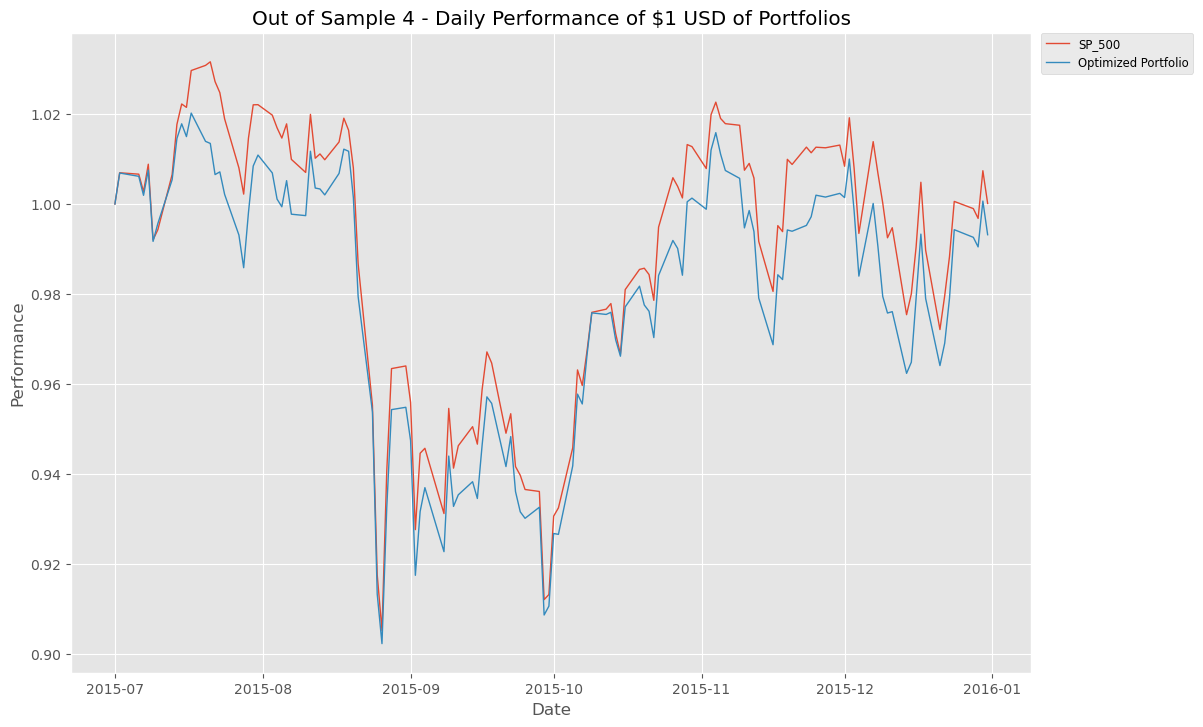

In [ ]:
# OUT OF SAMPLE 4 HISTORICAL(OOS4) PERFORMANCE

init = 1        #Initial Common Value (Can be thought of Initial Investment of $1 USD in each stock)

oos4_new_returns = pd.DataFrame(np.ones((len(oos4_daily_data),len(oos4_daily_data.columns))), index = oos4_daily_data.index, columns = oos4_daily_data.columns)
for j in range(1,len(oos4_daily_data.index)):
    oos4_new_returns.iloc[j] = oos4_new_returns.iloc[j-1]*(oos4_daily_data.iloc[j-1][oos4_daily_data.columns])
oos4_new_returns = pd.DataFrame(np.ones((len(oos4_daily_data),2)), index = oos4_daily_data.index, columns = oos4_daily_data.columns[-2:])
for j in range(1,len(oos4_daily_data.index)):
    oos4_new_returns.iloc[j] = oos4_new_returns.iloc[j-1]*(oos4_daily_data.iloc[j-1][oos2_daily_data.columns[-2:]]+1)
plt.style.use('ggplot')
fig = plt.figure(figsize=(12,8), dpi=100)
axes = fig.add_axes([0.1, 0.1, 0.8, 0.8])   # left, bottom, width, height (range 0 to 1)

# Plot on that set of axes
for i in range(0,len(oos4_daily_data.columns[-2:])):
        axes.plot(oos4_new_returns.index, oos4_new_returns.iloc[:,i], linewidth=1)

#axes.set_prop_cycle(cycler)
axes.set_xlabel('Date')
axes.set_ylabel('Performance')
axes.set_title('Out of Sample 4 - Daily Performance of $1 USD of Portfolios')
axes.legend(oos4_daily_data.columns[-2:], bbox_to_anchor=(1.01, 1), loc='upper left', borderaxespad=0, fontsize='small')

plt.show()


In [ ]:
# Fama French Monthly Data using getFamaFrenchFactors module
oos_4_ff3_monthly = gff.famaFrench3Factor(frequency='m')
oos_4_ff3_monthly.rename(columns={"date_ff_factors": 'Date'}, inplace=True)
oos_4_ff3_monthly.set_index('Date', inplace=True)
oos_4_ff3_monthly.index = oos_4_ff3_monthly.index.to_period('M').to_timestamp('D')
# Keeping Only the Dates in the monthly_data
oos_4_ff3_monthly = oos_4_ff3_monthly.loc[oos4_monthly_data.index]

In [ ]:
# Create an empty DataFrame to store the OOS 3 Stock Betas
oos4_stock_betas = pd.DataFrame()

# Iterate over the tickers list
for col in oos4_monthly_data.columns[:]:
    # Set the dependent variable (Return of stock i)
    y = oos4_monthly_data[col]

    # Set the independent variables (Fama French 3 Factors)
    X = oos_4_ff3_monthly[['Mkt-RF','SMB','HML']]

    # Fit the multiple linear regression model
    model = LinearRegression()
    model.fit(X, y)

    # Store the results in the DataFrame
    oos4_stock_betas[col] = [model.intercept_] + list(model.coef_)
oos4_stock_betas = oos4_stock_betas.T
oos4_stock_betas.columns = ['Intercept','Mkt-RF','SMB','HML']

In [ ]:
# TARGET FACTOR BETAS
mkt_opt = 0.90                                                               # PORTFOLIO TARGET MKT BETA
smb_opt = 0.10                                                               # PORTFOLIO TARGET SMB BETA
hml_opt = 0.05                                                              # PORTFOLIO TARGET HML BETA
oos4_base_weights = pd.DataFrame(oos1_weights['New Weights'].T)
B = 1000000

In [ ]:
#Stock Prices on the Day of OOS3 Optimization(Rebalancing)
oos4_stock_price = pd.DataFrame(yf.download(tickers,start=o4_start,end=o4_end,interval='1d')['Adj Close'])
oos4_stock_price = oos4_stock_price[-1:].tz_localize(None)
#Dictionary of Stock Prices on the Day of OOS2 Optimization(Rebalancing)
oos4_s_price = {}
oos4_s_keys = list(tickers)
oos4_s_values =  list(oos4_stock_price.iloc[0])
for key,value in zip(oos4_s_keys,oos4_s_values):
    oos4_s_price[key] = value

[*********************100%***********************]  445 of 445 completed


In [ ]:
#Transaction Costs on the Day of OOS3 Optimization(Rebalancing)
random.seed(3)
oos4_t_cost = {}
oos4_keys       = list(tickers)
#values     = [.15 for i in range(len(keys))]
oos4_values = list(random.uniform(0,.08) for i in range(len(tickers)))
for key,value in zip(oos4_keys,oos4_values):
    oos4_t_cost[key] = value

In [ ]:
# OPTIMIZATION MODEL

oos4_index = LpProblem('Index', LpMinimize)

# Decision Variables

oos4_wei = LpVariable.dicts('Weight',tickers,lowBound=0)             # Weights for stock i in the optimal portfolio
oos4_aux = LpVariable.dicts('Y',tickers,lowBound=0)                  # Absolute value of change for stock i from base weights
oos4_err = LpVariable.dicts('Error', oos4_monthly_data.index, lowBound=0) # Error term for portfolio
oos4_binary = LpVariable.dicts('bin',tickers,cat=LpBinary)           # Used if we want to limit the # of stocks we want to have in optimal portfolio
oos4_tr_cost = LpVariable.dicts('Transaction_Cost',tickers,lowBound=0)             # Weights for stock i in the optimal portfolio


#Objective Function - Minimize the error term
oos4_index +=  lpSum(oos4_err[t] for t in oos4_monthly_data.index)

# Constraint: Weights sum to 1
oos4_index += lpSum([oos4_wei[i] for i in tickers]) == 1

# Constraint: Absolute value of change in weights from base weigths
for i in tickers:
    oos4_index += oos4_aux[i] >= oos4_base_weights.loc[i]  - oos4_wei[i]
    oos4_index += oos4_aux[i] >= oos4_wei[i] - oos4_base_weights.loc[i]
oos4_index += lpSum(oos4_aux[i] for i in tickers) <= 1

# Constraint: Error term
for t in oos4_monthly_data.index:
    oos4_index += lpSum(oos4_wei[i]*(oos4_monthly_data.loc[t,i]-oos_4_ff3_monthly.loc[t,'RF']) for i in tickers) - oos4_err[t] <= (mkt_opt*oos_4_ff3_monthly.loc[t,'Mkt-RF']+smb_opt*oos_4_ff3_monthly.loc[t,'SMB']+hml_opt*oos_4_ff3_monthly.loc[t,'HML'])
    oos4_index += lpSum(oos4_wei[i]*(oos4_monthly_data.loc[t,i]-oos_4_ff3_monthly.loc[t,'RF']) for i in tickers) + oos4_err[t] >= (mkt_opt*oos_4_ff3_monthly.loc[t,'Mkt-RF']+smb_opt*oos_4_ff3_monthly.loc[t,'SMB']+hml_opt*oos_4_ff3_monthly.loc[t,'HML'])

# Transaction Costs
for i in tickers:
    oos4_index += lpSum(oos4_aux[i] * B * oos4_t_cost[i]/oos4_s_price[i]) == oos4_tr_cost[i]
oos4_index += lpSum(oos4_tr_cost[i] for i in tickers) <= 20000
# Limit # of stocks in Optimal Portfolio
for i in tickers: # Forces weight of stock i to be less than binary value of stock i. If stock is not selected binary variable is 0 which then forces weight of stock i to be in the optimal portfolio to be 0.
    oos4_index += oos4_wei[i] <= oos4_binary[i]

oos4_index += lpSum(oos4_binary[i] for i in tickers) <= 100

oos4_index.solve()

Welcome to the CBC MILP Solver 
Version: 2.10.3 
Build Date: Dec 15 2019 

command line - /Users/asimturk/opt/anaconda3/lib/python3.9/site-packages/pulp/apis/../solverdir/cbc/osx/64/cbc /var/folders/3h/z7y93q3521g6rhyrtbcqb9ym0000gn/T/39fa02063db3461d9e116a5df634ff41-pulp.mps timeMode elapsed branch printingOptions all solution /var/folders/3h/z7y93q3521g6rhyrtbcqb9ym0000gn/T/39fa02063db3461d9e116a5df634ff41-pulp.sol (default strategy 1)
At line 2 NAME          MODEL
At line 3 ROWS
At line 1861 COLUMNS
At line 40214 RHS
At line 42071 BOUNDS
At line 42517 ENDATA
Problem MODEL has 1856 rows, 1816 columns and 37426 elements
Coin0008I MODEL read with 0 errors
Option for timeMode changed from cpu to elapsed
Continuous objective value is 0 - 0.05 seconds
Cgl0003I 0 fixed, 0 tightened bounds, 49 strengthened rows, 0 substitutions
Cgl0004I processed model has 1015 rows, 1371 columns (445 integer (445 of which binary)) and 35793 elements
Cbc0038I Initial state - 37 integers unsatisfied sum - 1.

1

In [ ]:
oos4_tr_costt = pd.DataFrame([v.varValue for v in oos4_index.variables() if str(v.name)[0] == 'T'], index = [str(v.name) for v in oos4_index.variables() if str(v.name)[0] == 'T'] , columns = ['Optimal'])
oos4_tr_costt.sum()

Optimal    290.391983
dtype: float64

In [ ]:
oos4_auxx = pd.DataFrame([v.varValue for v in oos4_index.variables() if str(v.name)[0] == 'Y'], index = [str(v.name) for v in oos4_index.variables() if str(v.name)[0] == 'Y'] , columns = ['Optimal'])
oos4_auxx.sum()

Optimal    0.743205
dtype: float64

In [ ]:
oos4_errr = pd.DataFrame([v.varValue for v in oos4_index.variables() if str(v.name)[0] == 'E'], index = [str(v.name) for v in oos4_index.variables() if str(v.name)[0] == 'E'] , columns = ['Optimal'])
oos4_errr.sum()

Optimal    0.0
dtype: float64

In [ ]:
# Check if Binary Values Constraint works
oos4_binary_v = pd.DataFrame([v.varValue for v in oos4_index.variables() if v.varValue != 0 and str(v.name)[0] == 'b'], index = [str(v.name) for v in oos4_index.variables() if v.varValue != 0 and str(v.name)[0] == 'b'] , columns = ['Optimal'])
oos4_binary_v.sum()

Optimal    59.0
dtype: float64

In [ ]:
# Weights in Optimal Portfolio
oos4_opt_weights = pd.DataFrame([v.varValue for v in oos4_index.variables() if v.varValue != 0 and str(v.name)[0] == 'W'], index = [str(v.name) for v in oos4_index.variables() if v.varValue != 0 and str(v.name)[0] == 'W'] , columns = ['Optimal'])
oos4_opt_weights.style.format('{:,.2%}'.format)

,Optimal
Weight_ADBE,0.58%
Weight_ALB,1.22%
Weight_AMZN,1.11%
Weight_ATO,0.83%
Weight_AVB,0.50%
Weight_AXP,6.07%
Weight_BRO,2.62%
Weight_CAT,3.19%
Weight_CHRW,1.28%
Weight_CHTR,0.47%


In [ ]:
# WEIGHTS AND RETURNS OLD PORTFOLIO VS. NEW PORTFOLIO

oos4_weights_new = pd.DataFrame([v.varValue for v in oos4_index.variables() if str(v.name[0]) == 'W'], index = [str(v.name).split('_')[1] for v in oos4_index.variables() if str(v.name[0]) == 'W'] , columns = ['New Weights'])
oos4_weights = pd.DataFrame(np.zeros((len(oos4_monthly_data.columns[:-2]),3)), index=oos4_monthly_data.columns[:-2], columns=['PORTFOLIO Weights','Difference','New Weights'])
for t in oos4_monthly_data.columns[:-2]:
    oos4_weights.loc[t][0] = round(oos4_base_weights.loc[t],4)
    oos4_weights.loc[t][1] = round(oos4_weights_new.loc[t][0]-oos4_base_weights.loc[t][0],4)
    oos4_weights.loc[t][2] = oos4_weights_new.loc[t]
oos4_weights

,PORTFOLIO Weights,Difference,New Weights
A,0.0000,0.0000,0.0
AAL,0.0000,0.0000,0.0
AAP,0.0000,0.0000,0.0
AAPL,0.0000,0.0000,0.0
ABC,0.0000,0.0000,0.0
...,...,...,...
XRAY,0.0000,0.0000,0.0
YUM,0.0000,0.0000,0.0
ZBH,0.0101,-0.0101,0.0
ZBRA,0.0000,0.0000,0.0


In [ ]:
# CHECK PORTFOLIO BETAS

oos4_port_returns = pd.DataFrame(np.zeros((len(oos4_monthly_data.index),2)), index=oos4_monthly_data.index, columns=["Portfolio","Optimization"])
for j in oos4_port_returns.index:
    oos4_port_returns.loc[j]["Portfolio"] = oos4_monthly_data.loc[j]['Optimized Portfolio']
    oos4_port_returns.loc[j]['Optimization'] = oos4_monthly_data.loc[j,:oos4_monthly_data.columns[-3]].dot(oos4_weights['New Weights'])
oos4_port_returns = oos4_port_returns.merge(oos_4_ff3_monthly[['Mkt-RF','SMB','HML']], left_index=True, right_index=True)

# Create an empty DataFrame to store the Portfolio Beta
oos4_port_betas = pd.DataFrame(np.zeros((3,4)), index=oos_4_ff3_monthly.columns[0:3], columns=["Portfolio", "Target", "Optimization", "Abs. Diff"])

oos4_port_betas["Target"] = [mkt_opt, smb_opt, hml_opt]

# Set the independent variables (Fama French 3 Factors)
X = oos4_port_returns[['Mkt-RF','SMB','HML']]
# Set the dependent variable (Return of Portfolio)
Y = oos4_port_returns['Portfolio']
# Fit the oos4_port_returns linear regression model
regr = LinearRegression()
regr.fit(X,Y)
oos4_port_betas['Portfolio'] = regr.coef_

# Set the dependent variable (Return of Portfolio)
Y = oos4_port_returns['Optimization']
# Fit the multiple linear regression model
regr = LinearRegression()
regr.fit(X,Y)
oos4_port_betas['Optimization'] = regr.coef_

# Abs Difference between Target Betas & Optimal Portfolio Betas
oos4_port_betas["Abs. Diff"] = round(abs(oos4_port_betas['Optimization'] - oos4_port_betas["Target"]),4)
oos4_port_betas

,Portfolio,Target,Optimization,Abs. Diff
Mkt-RF,0.925255,0.90,0.899921,0.0001
SMB,0.046069,0.10,0.099885,0.0001
HML,0.017672,0.05,0.049814,0.0002


NO PERIODCIAL REBALANCING

In [ ]:
# OUT OF SAMPLE HISTORICAL(OOS) MONTHLY DATA (**After Optimization**) ONLY ONE REBALANCING NO PERIODICAL REBALANCING
o_start = '2013-12-01'
o_end   = '2016-01-01'
# OOS 1 Monthly Returns for Stocks in the List
oos_daily_data = yf.download(tickers,start=o_start,end=o_end,interval='1d')
# Turn Adj Close prices into pct returns
oos_daily_data = oos_daily_data['Adj Close'].pct_change().dropna()
#Reformat Date Index
oos_daily_data = oos_daily_data.tz_localize(None)
#Adding SP_500 data
oos_spy = pd.DataFrame(yf.download('^GSPC',start=o_start,end=o_end,interval='1d')['Adj Close'].pct_change())
oos_spy = oos_spy.drop(oos_spy.index[0]).tz_localize(None)
oos_daily_data['SP_500'] = oos_spy['Adj Close']
#Create a Column of Returns for Portfolio Returns
#oos1_monthly_data['Portfolio'] = ''
# Multiply weight of stock i and return of stock i to get Portfolio Returns
#for i in range(len(oos1_monthly_data.index)):
#    oos1_monthly_data.iloc[i,-1] = oos1_monthly_data.iloc[i,:-1].dot(base_w['Weight'])
#Create a Column of Returns for Optimal Portfolio Returns
oos_daily_data['No Rebalance - Optimized Portfolio'] = ''
# Multiply weight of stock i and return of stock i to get Optimal Portfolio Returns
for i in range(len(oos_daily_data.index)):
    oos_daily_data.iloc[i,-1] = oos_daily_data.iloc[i,:-2].dot(weights['New Weights'])


[*********************100%***********************]  445 of 445 completed
[*********************100%***********************]  1 of 1 completed


In [ ]:
oos_periodical_data = pd.concat([oos1_daily_data,oos2_daily_data,oos3_daily_data,oos4_daily_data])
oos_periodical_data = oos_periodical_data.iloc[:,-2:]

In [ ]:
oos_periodical_data['No Rebalance - Optimized Portfolio'] = oos_daily_data['No Rebalance - Optimized Portfolio']

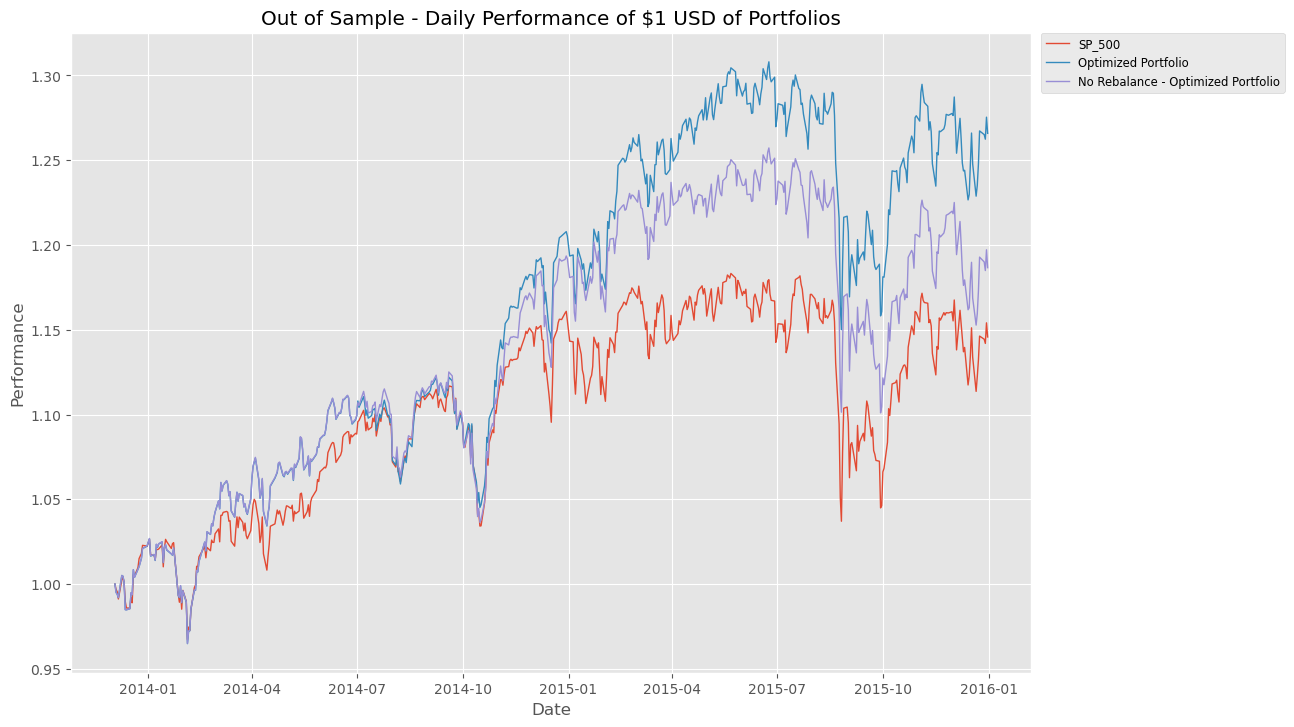

In [ ]:
# OUT OF SAMPLE HISTORICAL(OOS) PERFORMANCE

init = 1        #Initial Common Value (Can be thought of Initial Investment of $1 USD in each stock)

oos_periodical_new_returns = pd.DataFrame(np.ones((len(oos_periodical_data),len(oos_periodical_data.columns))), index = oos_periodical_data.index, columns = oos_periodical_data.columns)
for j in range(1,len(oos_periodical_data.index)):
    oos_periodical_new_returns.iloc[j] = oos_periodical_new_returns.iloc[j-1]*(oos_periodical_data.iloc[j-1][oos_periodical_data.columns])
oos_periodical_new_performance = pd.DataFrame(np.ones((len(oos_periodical_data),3)), index = oos_periodical_data.index, columns = oos_periodical_data.columns[-3:])
for j in range(1,len(oos_periodical_data.index)):
    oos_periodical_new_performance.iloc[j] = oos_periodical_new_performance.iloc[j-1]*(oos_periodical_data.iloc[j-1][oos_periodical_data.columns[-3:]]+1)
plt.style.use('ggplot')
fig = plt.figure(figsize=(12,8), dpi=100)
axes = fig.add_axes([0.1, 0.1, 0.8, 0.8])   # left, bottom, width, height (range 0 to 1)

# Plot on that set of axes

for i in range(0,len(oos_periodical_data.columns[-3:])):
        axes.plot(oos_periodical_new_performance.index, oos_periodical_new_performance.iloc[:,i], linewidth=1)

#axes.set_prop_cycle(cycler)
axes.set_xlabel('Date')
axes.set_ylabel('Performance')
axes.set_title('Out of Sample - Daily Performance of $1 USD of Portfolios')
axes.legend(oos_periodical_data.columns[-3:], bbox_to_anchor=(1.01, 1), loc='upper left', borderaxespad=0, fontsize='small')

plt.show()
